# UFC Model Comparison: Our ML Model vs. UFC Bet Companion

This notebook compares the predictive accuracy and profitability of our in-house ML fight outcome model against UFC Bet Companion's AI picks.

**Key questions:**
- How does overall accuracy compare?
- Who generates better ROI?
- On fights where we **disagree**, who is right more often — and by how much?
- What kinds of fights drive our edge (or lack thereof)?

---
## 1. Setup & Data Loading

In [1]:
import os
import sys
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

print('Libraries loaded.')

Libraries loaded.


In [2]:
# ── Load UFC Bet Companion Excel ──────────────────────────────────────────────
EXCEL_PATH = os.path.join(os.path.dirname(os.path.abspath('__file__')), 'ufc_bet_companion_picks.xlsx')

bc_fights      = pd.read_excel(EXCEL_PATH, sheet_name='Fights')
bc_events      = pd.read_excel(EXCEL_PATH, sheet_name='Events')
bc_comparison  = pd.read_excel(EXCEL_PATH, sheet_name='Comparison')

print(f'Fights sheet   : {bc_fights.shape}')
print(f'Events sheet   : {bc_events.shape}')
print(f'Comparison sheet: {bc_comparison.shape}')
print()
print('Fights columns :', bc_fights.columns.tolist())
print('Events columns :', bc_events.columns.tolist())
print('Comparison cols:', bc_comparison.columns.tolist())

Fights sheet   : (487, 11)
Events sheet   : (40, 7)
Comparison sheet: (544, 16)

Fights columns : ['Event', 'Event Accuracy', 'Event Profit ($)', 'Fighter A', 'Fighter B', 'Predicted Winner', 'Correct', 'Confidence', 'Odds at Prediction', 'Profit ($)', 'Fight URL']
Events columns : ['Event', 'Accuracy', 'Event Profit ($)', 'Fight Count', 'Correct', 'Wrong', 'No Result']
Comparison cols: ['Date', 'Event', 'Fight', 'Our Pick', 'Our Win %', 'Our Conviction %', 'BC Pick', 'BC Confidence', 'Agree?', 'Actual Winner', 'Our ✓/✗', 'BC ✓/✗', 'Odds (BC pick)', 'BC P&L ($100)', 'Our P&L ($100)', 'Notes']


In [3]:
# ── Load our past_predictions from Supabase ───────────────────────────────────
sys.path.insert(0, os.path.abspath('../'))
from db.database import engine
from sqlalchemy import text

QUERY = text("""
    SELECT DISTINCT ON (fight_id)
        fighter_a_name,
        fighter_b_name,
        event_name,
        event_date,
        win_prob_a,
        win_prob_b,
        predicted_winner_id,
        fighter_a_id,
        fighter_b_id,
        actual_winner_id,
        is_correct,
        confidence,
        prediction_source
    FROM past_predictions
    WHERE event_date >= '2025-03-01'
    ORDER BY fight_id, prediction_source DESC
""")

with engine.connect() as conn:
    our_preds = pd.read_sql(QUERY, conn)

our_preds['event_date'] = pd.to_datetime(our_preds['event_date'])

print(f'Our predictions loaded: {len(our_preds)} rows')
print(our_preds.dtypes)
our_preds.head()

Our predictions loaded: 550 rows
fighter_a_name                 object
fighter_b_name                 object
event_name                     object
event_date             datetime64[ns]
win_prob_a                    float64
win_prob_b                    float64
predicted_winner_id            object
fighter_a_id                   object
fighter_b_id                   object
actual_winner_id               object
is_correct                     object
confidence                    float64
prediction_source              object
dtype: object


,fighter_a_name,fighter_b_name,event_name,event_date,win_prob_a,win_prob_b,predicted_winner_id,fighter_a_id,fighter_b_id,actual_winner_id,is_correct,confidence,prediction_source
0,Kyoji Horiguchi,Tagir Ulanbekov,UFC Fight Night: Tsarukyan vs. Hooker,2025-11-22,0.477863,0.522137,f00ac08a,98aa60cf,f00ac08a,98aa60cf,False,0.044275,backfill
1,Azamat Murzakanov,Brendson Ribeiro,UFC 316: Dvalishvili vs. O'Malley 2,2025-06-07,0.545443,0.454557,e90a2f22,e90a2f22,49edd0d9,e90a2f22,True,0.090887,backfill
2,Paul Craig,Modestas Bukauskas,UFC Fight Night: Imavov vs. Borralho,2025-09-06,0.398530,0.601470,476fe566,eabf206b,476fe566,476fe566,True,0.202940,backfill
3,Da'Mon Blackshear,Davey Grant,UFC Fight Night: Whittaker vs. De Ridder,2025-07-26,0.507460,0.492540,da22387a,da22387a,113df4fd,113df4fd,False,0.014921,backfill
4,Ikram Aliskerov,JunYong Park,UFC 321: Aspinall vs. Gane,2025-10-25,0.423245,0.576755,285ae0b4,b07aed69,285ae0b4,b07aed69,False,0.153511,backfill


In [4]:
# ── Quick sanity checks ───────────────────────────────────────────────────────
print('=== Our Predictions ===')
print(f'Date range    : {our_preds["event_date"].min().date()} → {our_preds["event_date"].max().date()}')
print(f'Total fights  : {len(our_preds)}')
print(f'With result   : {our_preds["is_correct"].notna().sum()}')
print(f'Sources       : {our_preds["prediction_source"].value_counts().to_dict()}')

print()
print('=== UFC Bet Companion Fights Preview ===')
bc_fights.head(3)

=== Our Predictions ===
Date range    : 2025-03-01 → 2026-03-21
Total fights  : 550
With result   : 459
Sources       : {'backfill': 524, 'pre_fight_archive': 26}

=== UFC Bet Companion Fights Preview ===


,Event,Event Accuracy,Event Profit ($),Fighter A,Fighter B,Predicted Winner,Correct,Confidence,Odds at Prediction,Profit ($),Fight URL
0,Fight Night: Emmett vs Vallejos,0.5,-313.21,Josh Emmett,Kevin Vallejos,Kevin Vallejos,✓,71,-500,20.0,/event-fighter/4792-Josh%20Emmett%20vs%20Kevin...
1,Fight Night: Emmett vs Vallejos,0.5,-313.21,Amanda Lemos,Gillian Robertson,Amanda Lemos,✗,68,160,-100.0,/event-fighter/4715-Amanda%20Lemos%20vs%20Gill...
2,Fight Night: Emmett vs Vallejos,0.5,-313.21,Andre Fili,Jose Miguel Delgado,Andre Fili,✗,77,225,-100.0,/event-fighter/4925-Andre%20Fili%20vs%20Jose%2...


---
## 2. UFC Bet Companion — Overview

In [5]:
# ── Column normalisation ──────────────────────────────────────────────────────
# Hardcode the actual column names from the Excel sheets so nothing breaks.

def parse_correct(v):
    """Convert ✓/✗/· to True/False/None."""
    if v == '✓': return True
    if v == '✗': return False
    return None

# --- bc_fights: rename to snake_case ----------------------------------------
bc_fights.columns = [
    'event_name', 'event_accuracy', 'event_profit_usd',
    'fighter_a', 'fighter_b', 'bc_pick',
    'bc_correct_raw', 'bc_confidence', 'bc_odds', 'bc_profit', 'fight_url'
]
bc_fights['bc_correct'] = bc_fights['bc_correct_raw'].apply(parse_correct)
bc_fights['fight']      = bc_fights['fighter_a'] + ' vs ' + bc_fights['fighter_b']

# --- bc_events: rename -------------------------------------------------------
bc_events.columns = ['event_name', 'accuracy', 'event_profit', 'fight_count',
                      'correct', 'wrong', 'no_result']

# bc_events is scraped most-recent-first; reverse for chronological order
bc_events_chron = bc_events.iloc[::-1].reset_index(drop=True)
bc_events_chron['event_order'] = range(len(bc_events_chron))

# Merge event_order into bc_fights so we can sort chronologically
bc_fights = bc_fights.merge(
    bc_events_chron[['event_name', 'event_order']], on='event_name', how='left'
).sort_values('event_order').reset_index(drop=True)

# --- bc_comparison: rename ---------------------------------------------------
bc_comparison.columns = [
    'event_date', 'event_name', 'fight',
    'our_pick', 'our_win_pct', 'our_conviction_pct',
    'bc_pick', 'bc_confidence', 'agree_str',
    'actual_winner', 'our_correct_raw', 'bc_correct_raw',
    'bc_odds', 'bc_profit', 'our_profit', 'notes'
]
bc_comparison['our_correct'] = bc_comparison['our_correct_raw'].apply(parse_correct)
bc_comparison['bc_correct']  = bc_comparison['bc_correct_raw'].apply(parse_correct)
bc_comparison['agree']       = bc_comparison['agree_str'].str.contains('Agree', na=False)
bc_comparison['event_date']  = pd.to_datetime(bc_comparison['event_date'], errors='coerce')

# --- Set column-name variables used by later cells ---------------------------
COL_EVENT   = 'event_name'
COL_CORRECT = 'bc_correct'       # bool column in bc_fights
COL_PL      = 'bc_profit'
COL_CONF    = 'bc_confidence'
COL_ODDS    = 'bc_odds'
COL_PICK_TYPE = None              # no pick-type column in our scrape

print("Normalisation complete.")
print("bc_fights  :", bc_fights.columns.tolist())
print("bc_events  :", bc_events_chron.columns.tolist())
print("comparison :", bc_comparison.columns.tolist())

Normalisation complete.
bc_fights  : ['event_name', 'event_accuracy', 'event_profit_usd', 'fighter_a', 'fighter_b', 'bc_pick', 'bc_correct_raw', 'bc_confidence', 'bc_odds', 'bc_profit', 'fight_url', 'bc_correct', 'fight', 'event_order']
bc_events  : ['event_name', 'accuracy', 'event_profit', 'fight_count', 'correct', 'wrong', 'no_result', 'event_order']
comparison : ['event_date', 'event_name', 'fight', 'our_pick', 'our_win_pct', 'our_conviction_pct', 'bc_pick', 'bc_confidence', 'agree_str', 'actual_winner', 'our_correct_raw', 'bc_correct_raw', 'bc_odds', 'bc_profit', 'our_profit', 'notes', 'our_correct', 'bc_correct', 'agree']


In [6]:
# ── High-level UFC Bet Companion stats ────────────────────────────────────────
bc_resolved = bc_fights[bc_fights[COL_CORRECT].notna()].copy()
bc_resolved['correct_bool'] = bc_resolved[COL_CORRECT].astype(bool)

total_fights  = len(bc_fights)
total_events  = bc_fights[COL_EVENT].nunique()
overall_acc   = bc_resolved['correct_bool'].mean()
total_pl      = bc_resolved[COL_PL].sum()
total_staked  = len(bc_resolved) * 100
roi           = total_pl / total_staked * 100

print('=' * 45)
print('UFC BET COMPANION — OVERVIEW')
print('=' * 45)
print(f'Total fights tracked : {total_fights}')
print(f'Total events         : {total_events}')
print(f'Correct picks        : {bc_resolved["correct_bool"].sum()} / {len(bc_resolved)}')
print(f'Overall accuracy     : {overall_acc:.1%}')
print(f'Total P&L ($100 flat): ${total_pl:+,.2f}')
print(f'ROI                  : {roi:+.2f}%')

UFC BET COMPANION — OVERVIEW
Total fights tracked : 487
Total events         : 40
Correct picks        : 282 / 479
Overall accuracy     : 58.9%
Total P&L ($100 flat): $-1,275.09
ROI                  : -2.66%


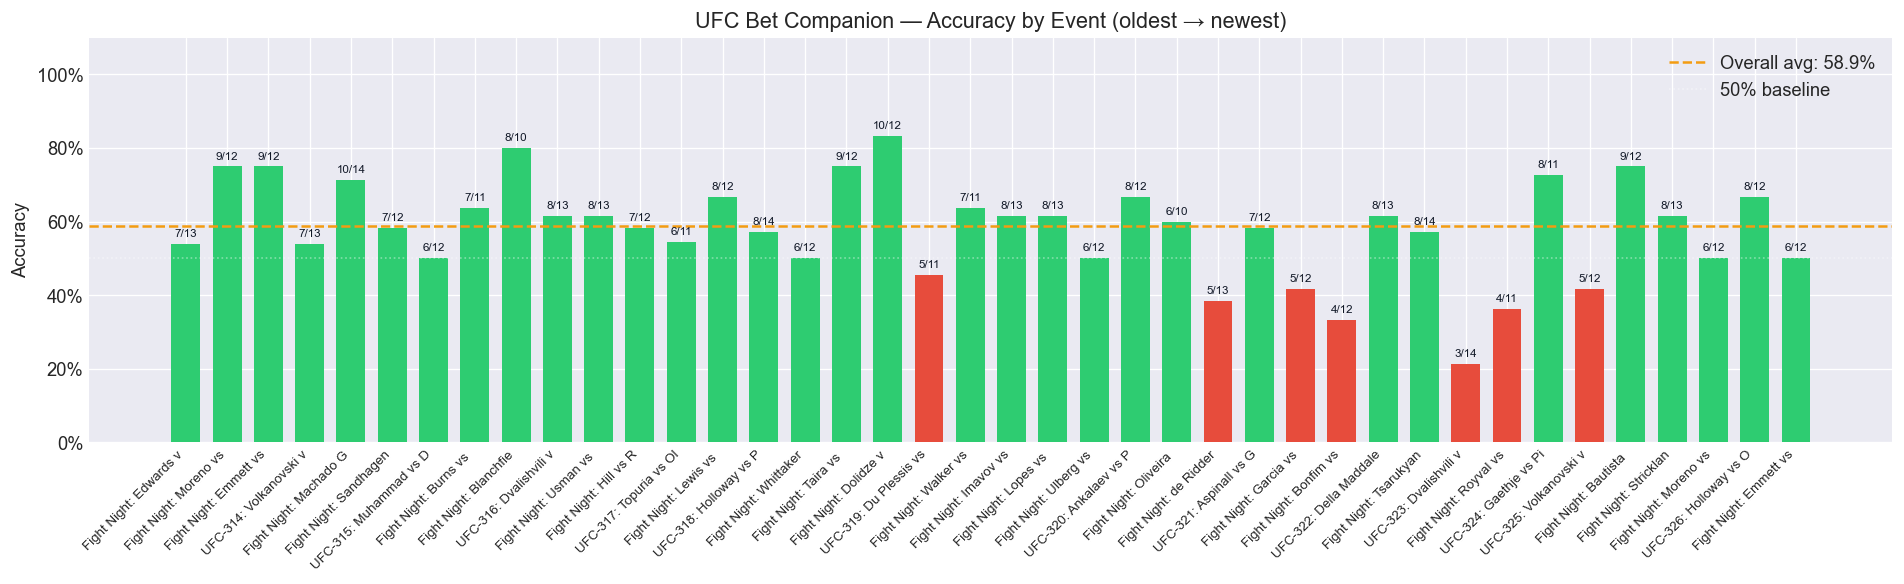

In [7]:
# ── Accuracy by event (bar chart) ─────────────────────────────────────────────
event_acc = bc_events_chron.copy()
event_acc['accuracy'] = event_acc['correct'] / event_acc['fight_count']

fig, ax = plt.subplots(figsize=(16, 5))
colors = ['#2ecc71' if a >= 0.5 else '#e74c3c' for a in event_acc['accuracy']]
ax.bar(range(len(event_acc)), event_acc['accuracy'], color=colors, edgecolor='none', width=0.7)
ax.axhline(overall_acc, color='#f39c12', linestyle='--', linewidth=1.5,
           label=f'Overall avg: {overall_acc:.1%}')
ax.axhline(0.5, color='white', linestyle=':', linewidth=1, alpha=0.4, label='50% baseline')
ax.set_xticks(range(len(event_acc)))
ax.set_xticklabels(
    [e[:22] for e in event_acc['event_name']],
    rotation=45, ha='right', fontsize=8
)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.set_ylim(0, 1.1)
ax.set_title('UFC Bet Companion — Accuracy by Event (oldest → newest)')
ax.set_ylabel('Accuracy')
ax.legend()

for i, row in event_acc.iterrows():
    ax.text(i, row['accuracy'] + 0.02,
            f"{int(row['correct'])}/{int(row['fight_count'])}",
            ha='center', fontsize=7, color='#111827')

plt.tight_layout()
plt.show()

---
## 3. UFC Bet Companion — Betting Patterns

In [8]:
# ── Pick type breakdown (favorite vs underdog) ────────────────────────────────
if COL_PICK_TYPE:
    pick_counts = bc_resolved[COL_PICK_TYPE].value_counts()

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Pie chart
    axes[0].pie(
        pick_counts.values,
        labels=pick_counts.index,
        autopct='%1.1f%%',
        colors=['#3498db', '#e67e22'],
        startangle=90,
        wedgeprops={'edgecolor': 'none'}
    )
    axes[0].set_title('UFC BC — Pick Distribution')

    # Accuracy by pick type
    acc_by_type = bc_resolved.groupby(COL_PICK_TYPE)['correct_bool'].agg(['mean', 'count']).reset_index()
    acc_by_type.columns = [COL_PICK_TYPE, 'accuracy', 'n']

    bar_colors = ['#3498db', '#e67e22'][:len(acc_by_type)]
    bars = axes[1].bar(acc_by_type[COL_PICK_TYPE], acc_by_type['accuracy'],
                       color=bar_colors, edgecolor='none', width=0.5)
    axes[1].axhline(0.5, color='white', linestyle=':', linewidth=1, alpha=0.5)
    axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
    axes[1].set_ylim(0, 1.0)
    axes[1].set_title('UFC BC — Accuracy by Pick Type')
    axes[1].set_ylabel('Accuracy')

    for bar, (_, row) in zip(bars, acc_by_type.iterrows()):
        axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
                     f'{row["accuracy"]:.1%}\n(n={int(row["n"])})',
                     ha='center', fontsize=10, color='#111827')

    plt.suptitle('UFC Bet Companion — Pick Type Analysis', y=1.01)
    plt.tight_layout()
    plt.show()
else:
    print('No pick_type column found — skipping pick type analysis.')

No pick_type column found — skipping pick type analysis.


In [9]:
# ── P&L by pick type (favorites vs underdogs) ─────────────────────────────────
if COL_PICK_TYPE and COL_PL:
    pl_by_type = bc_resolved.groupby(COL_PICK_TYPE)[COL_PL].sum().reset_index()
    pl_by_type.columns = [COL_PICK_TYPE, 'total_pl']

    fig, ax = plt.subplots(figsize=(7, 5))
    bar_colors = ['#2ecc71' if v >= 0 else '#e74c3c' for v in pl_by_type['total_pl']]
    bars = ax.bar(pl_by_type[COL_PICK_TYPE], pl_by_type['total_pl'],
                  color=bar_colors, edgecolor='none', width=0.5)
    ax.axhline(0, color='white', linewidth=0.8)
    ax.set_title('UFC BC — Total P&L by Pick Type ($100 flat stake)')
    ax.set_ylabel('Total P&L ($)')

    for bar, (_, row) in zip(bars, pl_by_type.iterrows()):
        y_offset = 5 if row['total_pl'] >= 0 else -15
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + y_offset,
                f'${row["total_pl"]:+.0f}', ha='center', fontsize=11, color='#111827')

    plt.tight_layout()
    plt.show()
else:
    print('No pick_type or P&L column found — skipping P&L by pick type.')

No pick_type or P&L column found — skipping P&L by pick type.


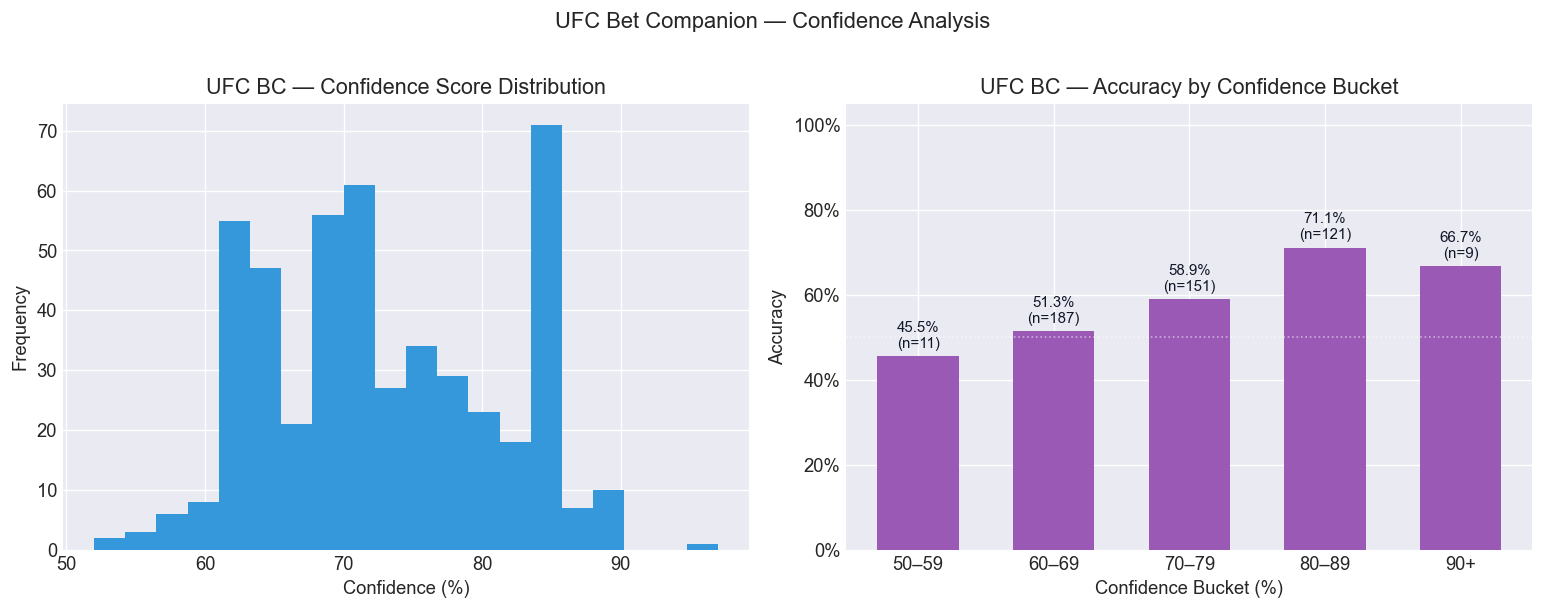

In [10]:
# ── Confidence score distribution ─────────────────────────────────────────────
if COL_CONF:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    # Histogram
    axes[0].hist(bc_resolved[COL_CONF].dropna(), bins=20, color='#3498db', edgecolor='none')
    axes[0].set_title('UFC BC — Confidence Score Distribution')
    axes[0].set_xlabel('Confidence (%)')
    axes[0].set_ylabel('Frequency')

    # Accuracy by confidence bucket
    bc_resolved['conf_bucket'] = pd.cut(
        bc_resolved[COL_CONF],
        bins=[0, 59, 69, 79, 89, 100],
        labels=['50–59', '60–69', '70–79', '80–89', '90+']
    )
    bucket_acc = bc_resolved.groupby('conf_bucket', observed=True)['correct_bool'].agg(['mean', 'count']).reset_index()
    bucket_acc.columns = ['bucket', 'accuracy', 'n']

    bars = axes[1].bar(bucket_acc['bucket'].astype(str), bucket_acc['accuracy'],
                       color='#9b59b6', edgecolor='none', width=0.6)
    axes[1].axhline(0.5, color='white', linestyle=':', linewidth=1, alpha=0.5)
    axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
    axes[1].set_ylim(0, 1.05)
    axes[1].set_title('UFC BC — Accuracy by Confidence Bucket')
    axes[1].set_xlabel('Confidence Bucket (%)')
    axes[1].set_ylabel('Accuracy')

    for bar, (_, row) in zip(bars, bucket_acc.iterrows()):
        axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
                     f'{row["accuracy"]:.1%}\n(n={int(row["n"])})',
                     ha='center', fontsize=9, color='#111827')

    plt.suptitle('UFC Bet Companion — Confidence Analysis', y=1.01)
    plt.tight_layout()
    plt.show()
else:
    print('No confidence column found — skipping confidence analysis.')

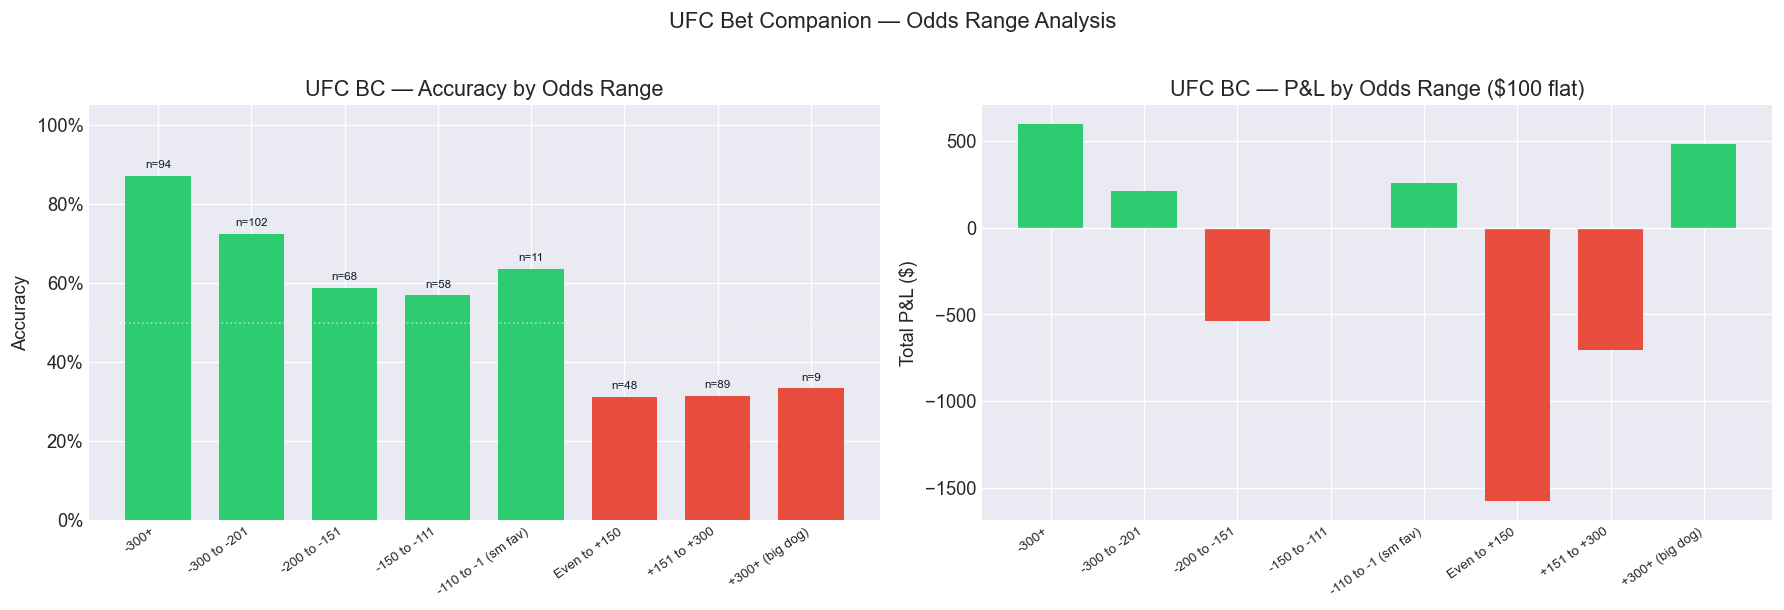

In [11]:
# ── Odds range analysis ───────────────────────────────────────────────────────
if COL_ODDS:
    bc_resolved['odds_numeric'] = pd.to_numeric(bc_resolved[COL_ODDS], errors='coerce')

    odds_bins   = [-9999, -301, -201, -151, -111, -1, 150, 300, 9999]
    odds_labels = ['-300+', '-300 to -201', '-200 to -151', '-150 to -111',
                   '-110 to -1 (sm fav)', 'Even to +150', '+151 to +300', '+300+ (big dog)']

    bc_resolved['odds_bucket'] = pd.cut(
        bc_resolved['odds_numeric'], bins=odds_bins, labels=odds_labels
    )

    odds_stats = (
        bc_resolved.groupby('odds_bucket', observed=True)
        .agg(
            accuracy=('correct_bool', 'mean'),
            n=('correct_bool', 'count'),
            total_pl=(COL_PL, 'sum') if COL_PL else ('correct_bool', 'count')
        )
        .reset_index()
    )

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    # Accuracy by odds range
    colors_acc = ['#2ecc71' if a >= 0.5 else '#e74c3c' for a in odds_stats['accuracy']]
    axes[0].bar(range(len(odds_stats)), odds_stats['accuracy'], color=colors_acc, edgecolor='none', width=0.7)
    axes[0].axhline(0.5, color='white', linestyle=':', linewidth=1, alpha=0.5)
    axes[0].set_xticks(range(len(odds_stats)))
    axes[0].set_xticklabels(odds_stats['odds_bucket'].astype(str), rotation=35, ha='right', fontsize=8)
    axes[0].yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
    axes[0].set_ylim(0, 1.05)
    axes[0].set_title('UFC BC — Accuracy by Odds Range')
    axes[0].set_ylabel('Accuracy')

    for i, row in odds_stats.iterrows():
        axes[0].text(list(odds_stats.index).index(i), row['accuracy'] + 0.02,
                     f'n={int(row["n"])}', ha='center', fontsize=7, color='#111827')

    # P&L by odds range
    if COL_PL:
        colors_pl = ['#2ecc71' if v >= 0 else '#e74c3c' for v in odds_stats['total_pl']]
        axes[1].bar(range(len(odds_stats)), odds_stats['total_pl'], color=colors_pl, edgecolor='none', width=0.7)
        axes[1].axhline(0, color='white', linewidth=0.8)
        axes[1].set_xticks(range(len(odds_stats)))
        axes[1].set_xticklabels(odds_stats['odds_bucket'].astype(str), rotation=35, ha='right', fontsize=8)
        axes[1].set_title('UFC BC — P&L by Odds Range ($100 flat)')
        axes[1].set_ylabel('Total P&L ($)')
    else:
        axes[1].text(0.5, 0.5, 'No P&L data', ha='center', va='center', transform=axes[1].transAxes)

    plt.suptitle('UFC Bet Companion — Odds Range Analysis', y=1.01)
    plt.tight_layout()
    plt.show()
else:
    print('No odds column found — skipping odds range analysis.')

---
## 4. Our Model — Overview

In [12]:
# ── Overall model performance ─────────────────────────────────────────────────
our_resolved   = our_preds[our_preds['is_correct'].notna()].copy()
our_resolved['is_correct'] = our_resolved['is_correct'].astype(bool)

our_total      = len(our_preds)
our_with_pred  = len(our_resolved)
our_accuracy   = our_resolved['is_correct'].mean()

print('=' * 45)
print('OUR MODEL — OVERVIEW')
print('=' * 45)
print(f'Total fights   : {our_total}')
print(f'With results   : {our_with_pred}')
print(f'Correct picks  : {our_resolved["is_correct"].sum()}')
print(f'Accuracy       : {our_accuracy:.1%}')
print()
print('Conviction stats (confidence):')
print(our_resolved['confidence'].describe().round(3))

OUR MODEL — OVERVIEW
Total fights   : 550
With results   : 459
Correct picks  : 295
Accuracy       : 64.3%

Conviction stats (confidence):
count    459.000
mean       0.137
std        0.091
min        0.001
25%        0.063
50%        0.124
75%        0.195
max        0.449
Name: confidence, dtype: float64


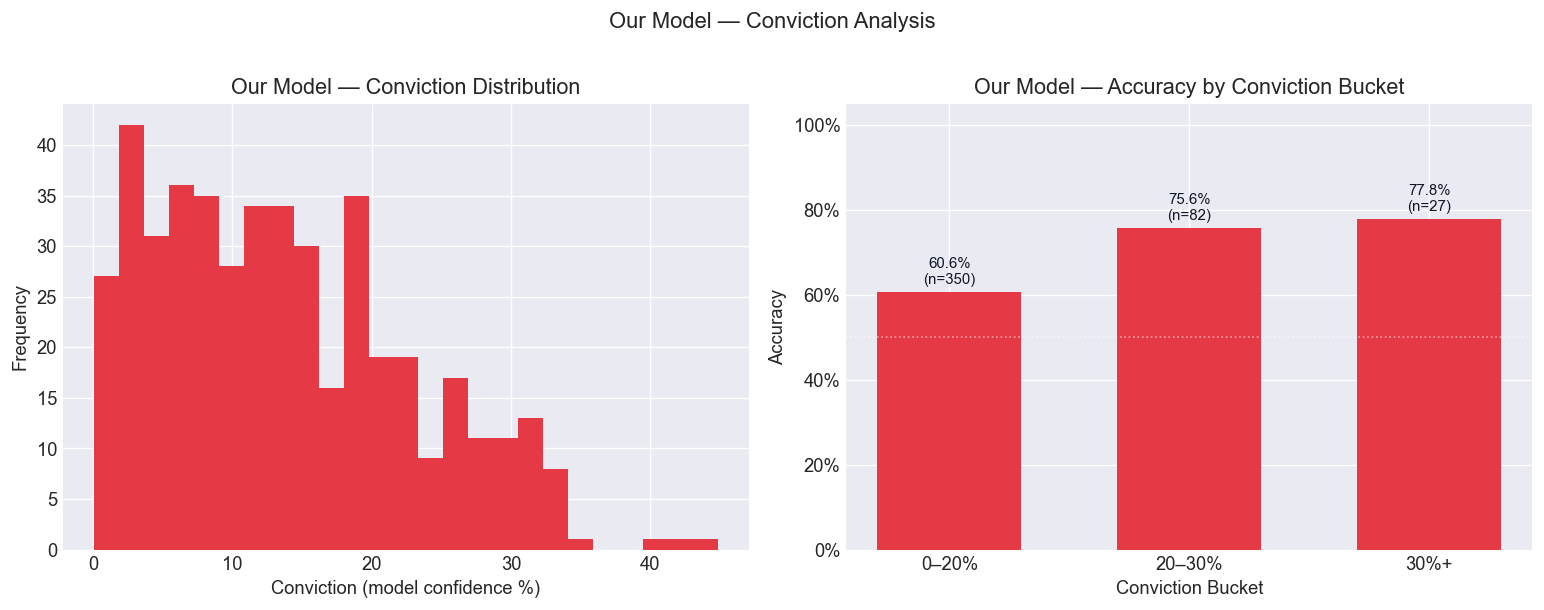

In [13]:
# ── Conviction distribution + accuracy by conviction bucket ───────────────────
our_resolved['conviction_pct'] = our_resolved['confidence'] * 100

our_resolved['conv_bucket'] = pd.cut(
    our_resolved['conviction_pct'],
    bins=[0, 20, 30, 100],
    labels=['0–20%', '20–30%', '30%+']
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Histogram
axes[0].hist(our_resolved['conviction_pct'].dropna(), bins=25, color='#e63946', edgecolor='none')
axes[0].set_title('Our Model — Conviction Distribution')
axes[0].set_xlabel('Conviction (model confidence %)')
axes[0].set_ylabel('Frequency')

# Accuracy by conviction bucket
conv_bucket_acc = (
    our_resolved.groupby('conv_bucket', observed=True)['is_correct']
    .agg(['mean', 'count'])
    .reset_index()
)
conv_bucket_acc.columns = ['bucket', 'accuracy', 'n']

bars = axes[1].bar(
    conv_bucket_acc['bucket'].astype(str),
    conv_bucket_acc['accuracy'],
    color='#e63946', edgecolor='none', width=0.6
)
axes[1].axhline(0.5, color='white', linestyle=':', linewidth=1, alpha=0.5)
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
axes[1].set_ylim(0, 1.05)
axes[1].set_title('Our Model — Accuracy by Conviction Bucket')
axes[1].set_xlabel('Conviction Bucket')
axes[1].set_ylabel('Accuracy')

for bar, (_, row) in zip(bars, conv_bucket_acc.iterrows()):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.02,
        f'{row["accuracy"]:.1%}\n(n={int(row["n"])})',
        ha='center', fontsize=9, color='#111827'
    )

plt.suptitle('Our Model — Conviction Analysis', y=1.01)
plt.tight_layout()
plt.show()

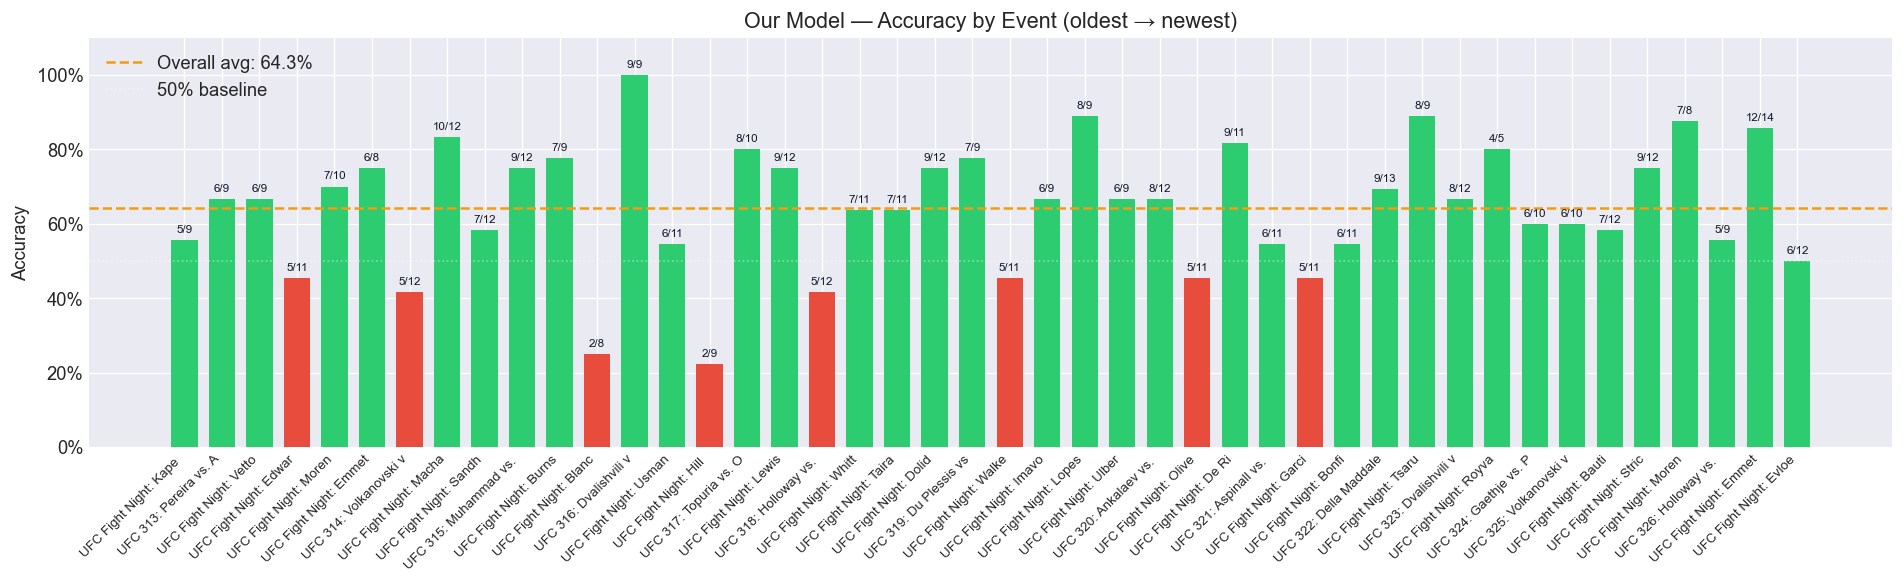

In [14]:
# ── Our model accuracy by event (oldest → newest) ─────────────────────────────
# Exclude Road to UFC / developmental events — not covered by UFC BC
our_event_acc = (
    our_resolved[~our_resolved['event_name'].str.contains('Road to UFC', case=False, na=False)]
    .groupby(['event_name', 'event_date'])
    .agg(correct=('is_correct', 'sum'), total=('is_correct', 'count'))
    .reset_index()
    .sort_values('event_date')
    .reset_index(drop=True)
)
our_event_acc['accuracy'] = our_event_acc['correct'] / our_event_acc['total']

fig, ax = plt.subplots(figsize=(16, 5))
colors = ['#2ecc71' if a >= 0.5 else '#e74c3c' for a in our_event_acc['accuracy']]
ax.bar(range(len(our_event_acc)), our_event_acc['accuracy'],
       color=colors, edgecolor='none', width=0.7)
ax.axhline(our_accuracy, color='#f39c12', linestyle='--', linewidth=1.5,
           label=f'Overall avg: {our_accuracy:.1%}')
ax.axhline(0.5, color='white', linestyle=':', linewidth=1, alpha=0.4, label='50% baseline')
ax.set_xticks(range(len(our_event_acc)))
ax.set_xticklabels(
    [e[:22] for e in our_event_acc['event_name']],
    rotation=45, ha='right', fontsize=8
)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.set_ylim(0, 1.1)
ax.set_title('Our Model — Accuracy by Event (oldest → newest)')
ax.set_ylabel('Accuracy')
ax.legend()

for i, row in our_event_acc.iterrows():
    ax.text(i, row['accuracy'] + 0.02,
            f"{int(row['correct'])}/{int(row['total'])}",
            ha='center', fontsize=7, color='#111827')

plt.tight_layout()
plt.show()

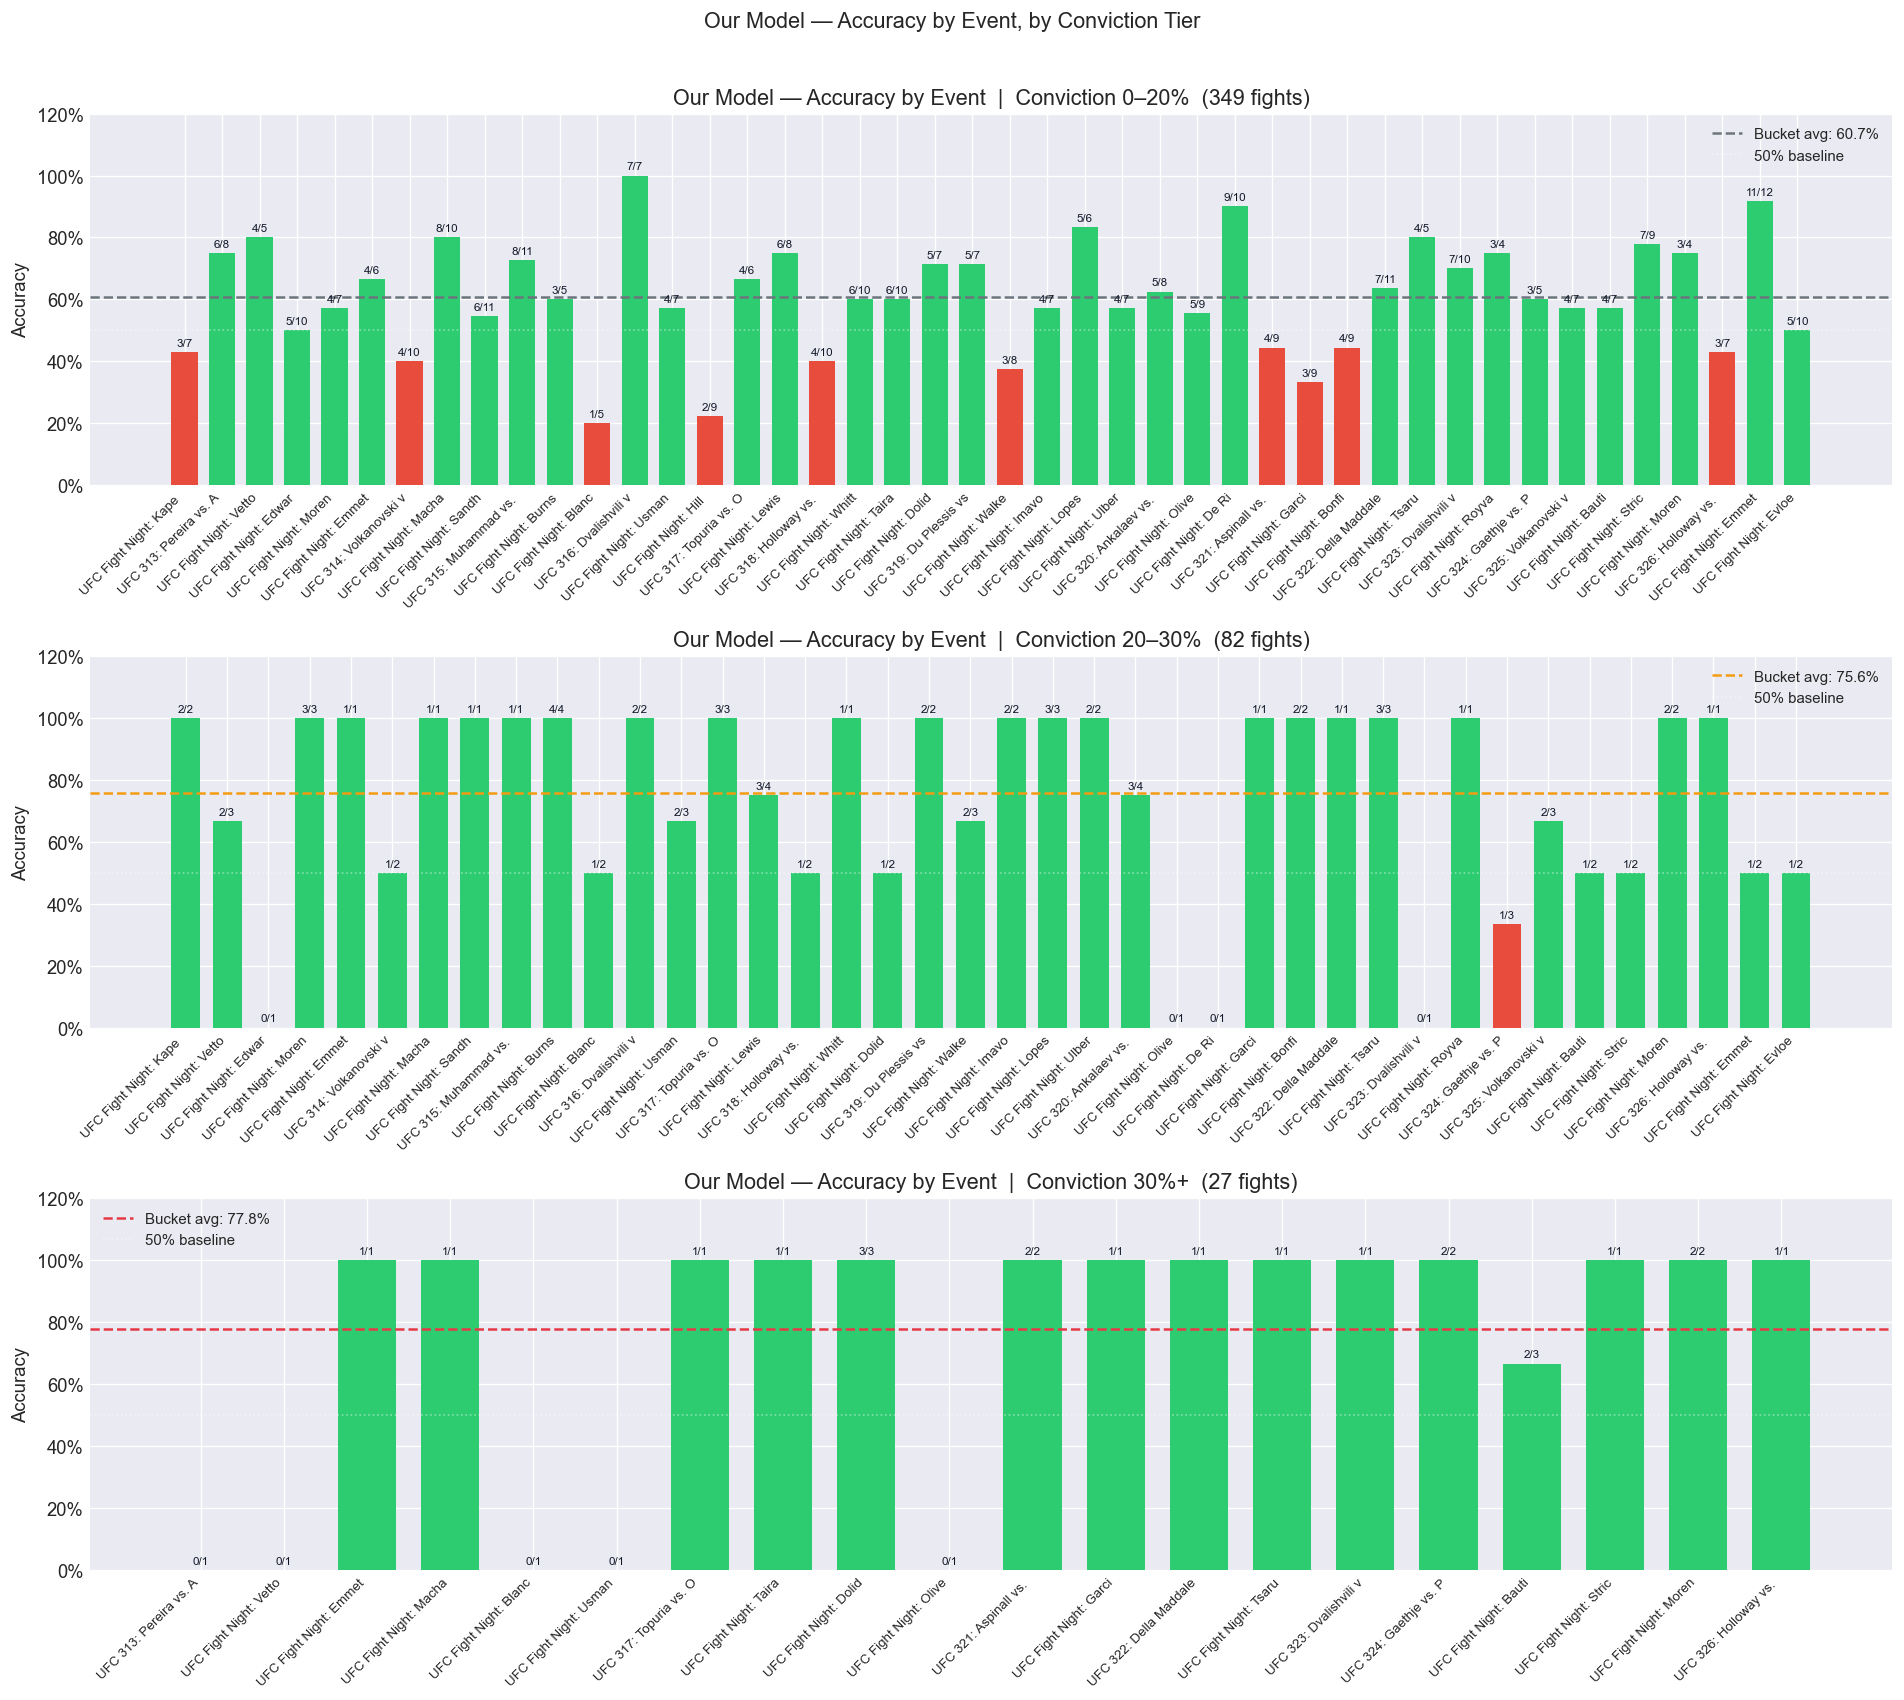

In [15]:
# ── Accuracy by event, split by conviction bucket ─────────────────────────────
# Same chart as above but one subplot per conviction tier (0-20%, 20-30%, 30%+)
# so we can see where the model goes right/wrong at each confidence level

buckets = ['0–20%', '20–30%', '30%+']
bucket_colors = {'0–20%': '#6c757d', '20–30%': '#f39c12', '30%+': '#e63946'}

fig, axes = plt.subplots(3, 1, figsize=(16, 14))

for ax, bucket in zip(axes, buckets):
    subset = our_resolved[
        (~our_resolved['event_name'].str.contains('Road to UFC', case=False, na=False)) &
        (our_resolved['conv_bucket'] == bucket)
    ]

    if subset.empty:
        ax.text(0.5, 0.5, f'No fights in {bucket} bucket', ha='center', va='center',
                transform=ax.transAxes)
        ax.set_title(f'Our Model — Accuracy by Event  |  Conviction {bucket}')
        continue

    ev_acc = (
        subset.groupby(['event_name', 'event_date'])
        .agg(correct=('is_correct', 'sum'), total=('is_correct', 'count'))
        .reset_index()
        .sort_values('event_date')
        .reset_index(drop=True)
    )
    ev_acc['accuracy'] = ev_acc['correct'] / ev_acc['total']
    overall = ev_acc['correct'].sum() / ev_acc['total'].sum()

    bar_colors = ['#2ecc71' if a >= 0.5 else '#e74c3c' for a in ev_acc['accuracy']]
    ax.bar(range(len(ev_acc)), ev_acc['accuracy'], color=bar_colors, edgecolor='none', width=0.7)
    ax.axhline(overall, color=bucket_colors[bucket], linestyle='--', linewidth=1.5,
               label=f'Bucket avg: {overall:.1%}')
    ax.axhline(0.5, color='white', linestyle=':', linewidth=1, alpha=0.4, label='50% baseline')
    ax.set_xticks(range(len(ev_acc)))
    ax.set_xticklabels([e[:22] for e in ev_acc['event_name']],
                       rotation=45, ha='right', fontsize=8)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
    ax.set_ylim(0, 1.2)
    ax.set_title(f'Our Model — Accuracy by Event  |  Conviction {bucket}  '
                 f'({int(ev_acc["total"].sum())} fights)')
    ax.set_ylabel('Accuracy')
    ax.legend(fontsize=9)

    for i, row in ev_acc.iterrows():
        ax.text(i, row['accuracy'] + 0.02,
                f"{int(row['correct'])}/{int(row['total'])}",
                ha='center', fontsize=7, color='#111827')

plt.suptitle('Our Model — Accuracy by Event, by Conviction Tier', y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

---
## 5. Head-to-Head Comparison

In [16]:
# ── Load & inspect Comparison sheet ──────────────────────────────────────────
# Expected Comparison columns:
#   fight_id / fight label, our_pick, bc_pick, actual_winner,
#   our_correct (bool), bc_correct (bool), agreement (bool)

cmp = bc_comparison.copy()
print('Comparison sheet columns:')
print(cmp.columns.tolist())
print(f'Total matched fights: {len(cmp)}')
cmp.head(3)

Comparison sheet columns:
['event_date', 'event_name', 'fight', 'our_pick', 'our_win_pct', 'our_conviction_pct', 'bc_pick', 'bc_confidence', 'agree_str', 'actual_winner', 'our_correct_raw', 'bc_correct_raw', 'bc_odds', 'bc_profit', 'our_profit', 'notes', 'our_correct', 'bc_correct', 'agree']
Total matched fights: 544


,event_date,event_name,fight,our_pick,our_win_pct,our_conviction_pct,bc_pick,bc_confidence,agree_str,actual_winner,our_correct_raw,bc_correct_raw,bc_odds,bc_profit,our_profit,notes,our_correct,bc_correct,agree
0,2026-03-14,Fight Night: Emmett vs Vallejos,Josh Emmett vs Kevin Vallejos,Kevin Vallejos,59.4,18.7,Kevin Vallejos,71,✓ Agree,Kevin Vallejos,✓,✓,-500.0,20.0,20.00,NaN,True,True,True
1,2026-03-14,Fight Night: Emmett vs Vallejos,Amanda Lemos vs Gillian Robertson,Gillian Robertson,60.7,21.4,Amanda Lemos,68,✗ Differ,Gillian Robertson,✓,✗,160.0,-100.0,62.50,NaN,True,False,False
2,2026-03-14,Fight Night: Emmett vs Vallejos,Andre Fili vs Jose Miguel Delgado,Jose Delgado,57.4,14.8,Andre Fili,77,✗ Differ,Jose Delgado,✓,✗,225.0,-100.0,44.44,NaN,True,False,False


In [17]:
# ── Compute accuracy segments from comparison data ───────────────────────────
# Filter to fights where both models and actual outcome are known
cmp_resolved = cmp.dropna(subset=['our_correct', 'bc_correct'])
total_matched = len(cmp_resolved)

agree_df    = cmp_resolved[cmp_resolved['agree'] == True]
disagree_df = cmp_resolved[cmp_resolved['agree'] == False]

n_agree    = len(agree_df)
n_disagree = len(disagree_df)

our_acc_overall  = cmp_resolved['our_correct'].mean()
bc_acc_overall   = cmp_resolved['bc_correct'].mean()

our_acc_agree    = agree_df['our_correct'].mean() if n_agree > 0 else 0
bc_acc_agree     = agree_df['bc_correct'].mean()  if n_agree > 0 else 0

our_acc_disagree = disagree_df['our_correct'].mean() if n_disagree > 0 else 0
bc_acc_disagree  = disagree_df['bc_correct'].mean()  if n_disagree > 0 else 0

print(f'Total matched fights (both resolved): {total_matched}')
print(f'  Agreements:    {n_agree}  | Disagreements: {n_disagree}')
print(f'Our overall:     {our_acc_overall:.1%}  | BC overall:     {bc_acc_overall:.1%}')
print(f'Agreements acc:  {our_acc_agree:.1%} (identical for both by definition)')
print(f'Our disagree:    {our_acc_disagree:.1%}  | BC disagree:    {bc_acc_disagree:.1%}')

Total matched fights (both resolved): 410
  Agreements:    244  | Disagreements: 166
Our overall:     65.1%  | BC overall:     59.8%
Agreements acc:  70.9% (identical for both by definition)
Our disagree:    56.6%  | BC disagree:    43.4%


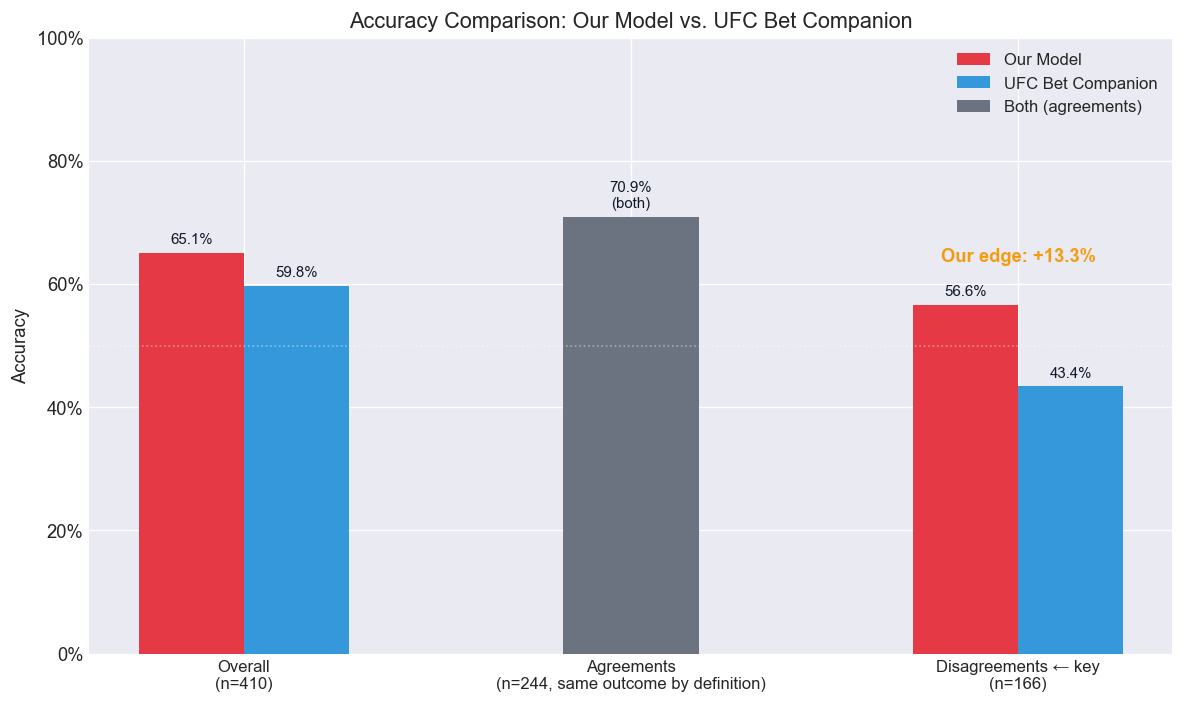

In [18]:
# ── Accuracy comparison chart ─────────────────────────────────────────────────
# NOTE on agreements:
# When both models pick the same fighter, they are BOTH correct or BOTH wrong
# by definition — their accuracy on agreements is always identical.
# So agreements are shown as a single bar (shared accuracy), while disagreements
# show two separate bars (the only segment where accuracy can actually differ).

fig, ax = plt.subplots(figsize=(10, 6))

width = 0.38
x_overall  = 0
x_agree    = 1.4
x_disagree = 2.8

# Overall — two bars
ax.bar(x_overall - width/2, our_acc_overall, width,
       color='#e63946', label='Our Model')
ax.bar(x_overall + width/2, bc_acc_overall,  width,
       color='#3498db', label='UFC Bet Companion')

# Agreements — single bar (identical for both, show as neutral grey)
ax.bar(x_agree, our_acc_agree, width * 1.3,
       color='#6b7280', label='Both (agreements)')

# Disagreements — two bars (the real comparison)
ax.bar(x_disagree - width/2, our_acc_disagree, width, color='#e63946')
ax.bar(x_disagree + width/2, bc_acc_disagree,  width, color='#3498db')

ax.axhline(0.5, color='white', linestyle=':', linewidth=1, alpha=0.4)
ax.set_xticks([x_overall, x_agree, x_disagree])
ax.set_xticklabels([
    f'Overall\n(n={total_matched})',
    f'Agreements\n(n={n_agree}, same outcome by definition)',
    f'Disagreements ← key\n(n={n_disagree})'
], fontsize=10)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.set_ylim(0, 1.0)
ax.set_title('Accuracy Comparison: Our Model vs. UFC Bet Companion')
ax.set_ylabel('Accuracy')
ax.legend(fontsize=10)

# Annotate all bars
for x, h, label in [
    (x_overall - width/2, our_acc_overall,  f'{our_acc_overall:.1%}'),
    (x_overall + width/2, bc_acc_overall,   f'{bc_acc_overall:.1%}'),
    (x_agree,             our_acc_agree,    f'{our_acc_agree:.1%}\n(both)'),
    (x_disagree - width/2, our_acc_disagree, f'{our_acc_disagree:.1%}'),
    (x_disagree + width/2, bc_acc_disagree,  f'{bc_acc_disagree:.1%}'),
]:
    ax.text(x, h + 0.015, label, ha='center', fontsize=9, color='#111827')

# Highlight the disagreement edge
delta = our_acc_disagree - bc_acc_disagree
edge_label = f'Our edge: {delta:+.1%}' if delta > 0 else f'Their edge: {delta:+.1%}'
ax.annotate(
    edge_label,
    xy=(x_disagree, max(our_acc_disagree, bc_acc_disagree) + 0.07),
    ha='center', fontsize=11, color='#f39c12', fontweight='bold'
)

plt.tight_layout()
plt.show()

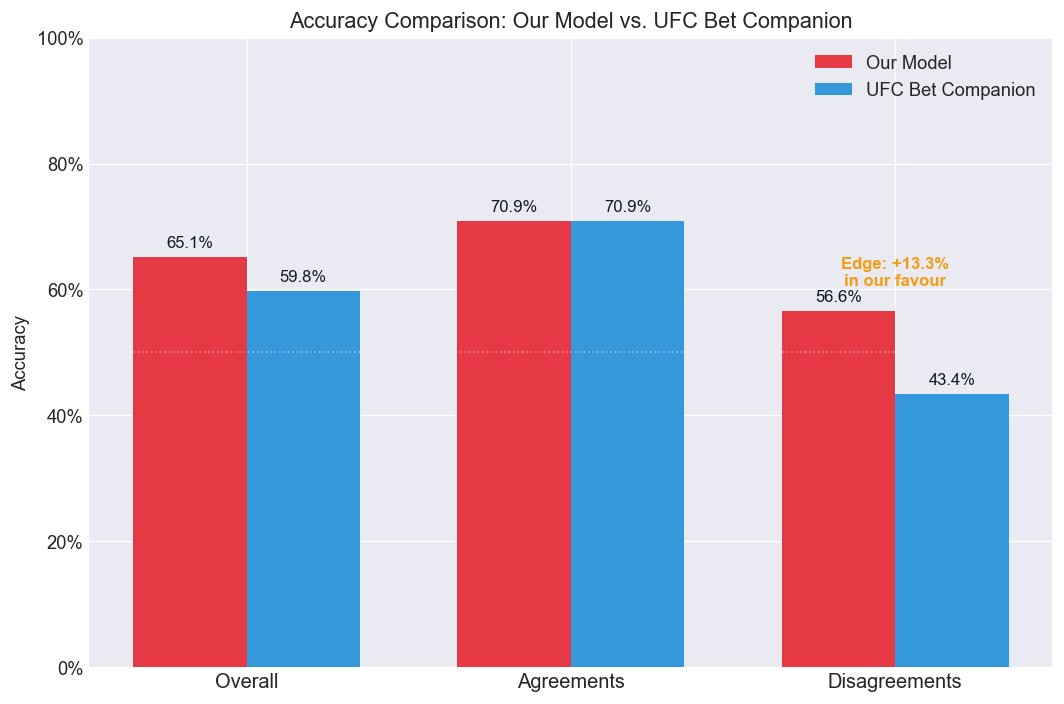

In [19]:
# ── Grouped bar chart: accuracy across segments ───────────────────────────────
segments  = ['Overall', 'Agreements', 'Disagreements']
our_accs  = [our_acc_overall, our_acc_agree, our_acc_disagree]
bc_accs   = [bc_acc_overall,  bc_acc_agree,  bc_acc_disagree]

x     = np.arange(len(segments))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 6))
bars_our = ax.bar(x - width/2, our_accs, width, label='Our Model', color='#e63946', edgecolor='none')
bars_bc  = ax.bar(x + width/2, bc_accs,  width, label='UFC Bet Companion', color='#3498db', edgecolor='none')

ax.axhline(0.5, color='white', linestyle=':', linewidth=1, alpha=0.4)
ax.set_xticks(x)
ax.set_xticklabels(segments, fontsize=12)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.set_ylim(0, 1.0)
ax.set_title('Accuracy Comparison: Our Model vs. UFC Bet Companion')
ax.set_ylabel('Accuracy')
ax.legend()

for bar in bars_our:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.015,
            f'{bar.get_height():.1%}', ha='center', fontsize=10, color='#111827')
for bar in bars_bc:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.015,
            f'{bar.get_height():.1%}', ha='center', fontsize=10, color='#111827')

# Annotate disagreement delta
delta = our_acc_disagree - bc_acc_disagree
ax.annotate(
    f'Edge: {delta:+.1%}\nin our favour' if delta > 0 else f'Edge: {delta:+.1%}\nin their favour',
    xy=(2, max(our_acc_disagree, bc_acc_disagree) + 0.04),
    ha='center', fontsize=10,
    color='#f39c12',
    fontweight='bold'
)

plt.tight_layout()
plt.show()

---
## 6. P&L Comparison

In [20]:
# ── P&L columns — already in comparison df as 'bc_profit' and 'our_profit' ───
CMP_BC_PL  = 'bc_profit'
CMP_OUR_PL = 'our_profit'
CMP_ODDS   = 'bc_odds'

print(f'BC  P&L column : {CMP_BC_PL}')
print(f'Our P&L column : {CMP_OUR_PL}')
print(f'Odds column    : {CMP_ODDS}')

# Quick check
print(f'\nBC  P&L non-null : {cmp_resolved[CMP_BC_PL].notna().sum()} / {len(cmp_resolved)}')
print(f'Our P&L non-null : {cmp_resolved[CMP_OUR_PL].notna().sum()} / {len(cmp_resolved)}')

BC  P&L column : bc_profit
Our P&L column : our_profit
Odds column    : bc_odds

BC  P&L non-null : 410 / 410
Our P&L non-null : 410 / 410


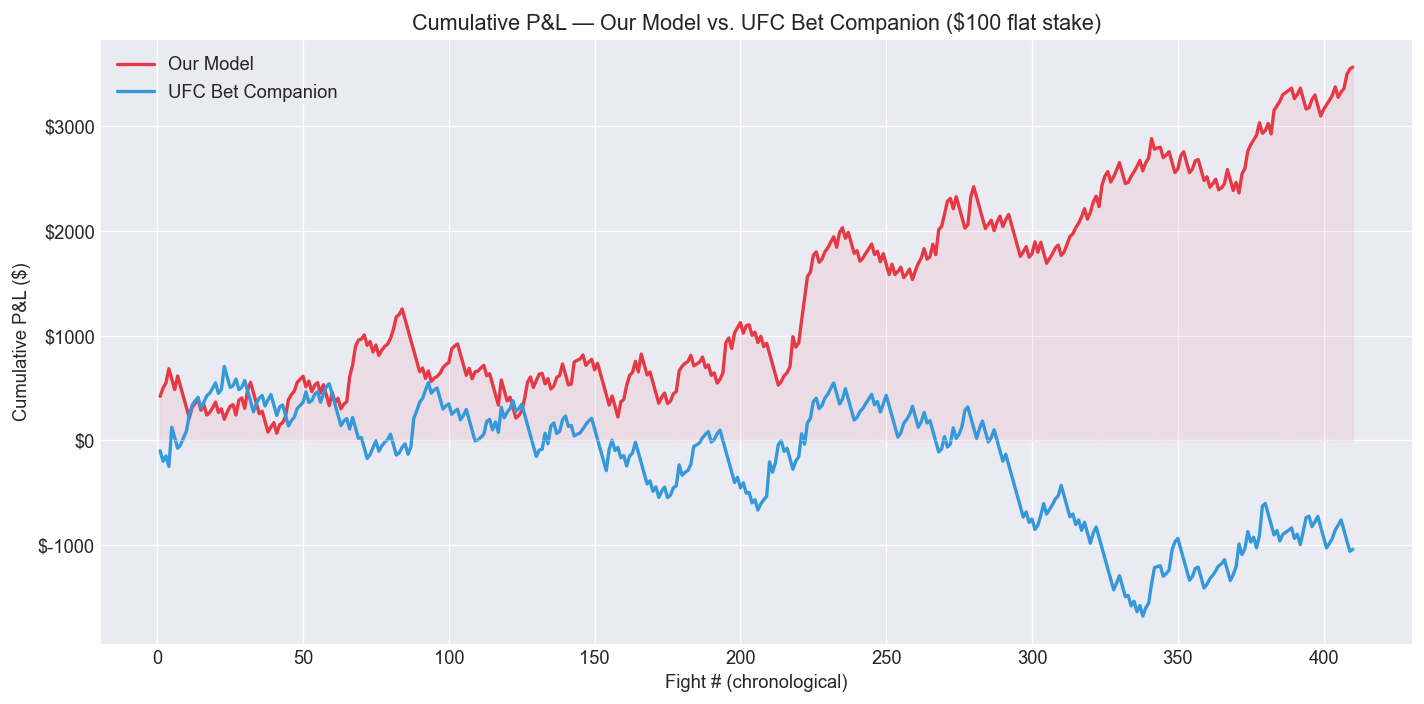

P&L Summary (410 fights, $100 flat stake):
  Our Model        : $+3,566.49  (ROI: +8.7%)
  UFC Bet Companion: $-1,040.53  (ROI: -2.5%)


In [21]:
# ── Cumulative P&L over time ──────────────────────────────────────────────────
cmp_sorted = cmp_resolved.copy()
cmp_sorted = cmp_sorted.sort_values('event_date').reset_index(drop=True)

cmp_sorted['our_cumpl'] = cmp_sorted[CMP_OUR_PL].fillna(0).cumsum()
cmp_sorted['bc_cumpl']  = cmp_sorted[CMP_BC_PL].fillna(0).cumsum()

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(cmp_sorted.index + 1, cmp_sorted['our_cumpl'], color='#e63946', linewidth=2, label='Our Model')
ax.plot(cmp_sorted.index + 1, cmp_sorted['bc_cumpl'],  color='#3498db', linewidth=2, label='UFC Bet Companion')
ax.axhline(0, color='white', linewidth=0.8, linestyle='--', alpha=0.4)
ax.fill_between(cmp_sorted.index + 1, cmp_sorted['our_cumpl'], 0,
                where=cmp_sorted['our_cumpl'] >= 0, alpha=0.08, color='#e63946')
ax.fill_between(cmp_sorted.index + 1, cmp_sorted['our_cumpl'], 0,
                where=cmp_sorted['our_cumpl'] < 0,  alpha=0.08, color='#e74c3c')
ax.set_xlabel('Fight # (chronological)')
ax.set_ylabel('Cumulative P&L ($)')
ax.set_title('Cumulative P&L — Our Model vs. UFC Bet Companion ($100 flat stake)')
ax.legend(fontsize=11)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('$%.0f'))
plt.tight_layout()
plt.show()

our_total_pl = cmp_sorted[CMP_OUR_PL].sum()
bc_total_pl  = cmp_sorted[CMP_BC_PL].sum()
n_matched_pl = cmp_sorted[CMP_OUR_PL].notna().sum()
our_roi      = our_total_pl / (len(cmp_sorted) * 100) * 100
bc_roi       = bc_total_pl  / (len(cmp_sorted) * 100) * 100

print(f'P&L Summary ({len(cmp_sorted)} fights, $100 flat stake):')
print(f'  Our Model        : ${our_total_pl:+,.2f}  (ROI: {our_roi:+.1f}%)')
print(f'  UFC Bet Companion: ${bc_total_pl:+,.2f}  (ROI: {bc_roi:+.1f}%)')

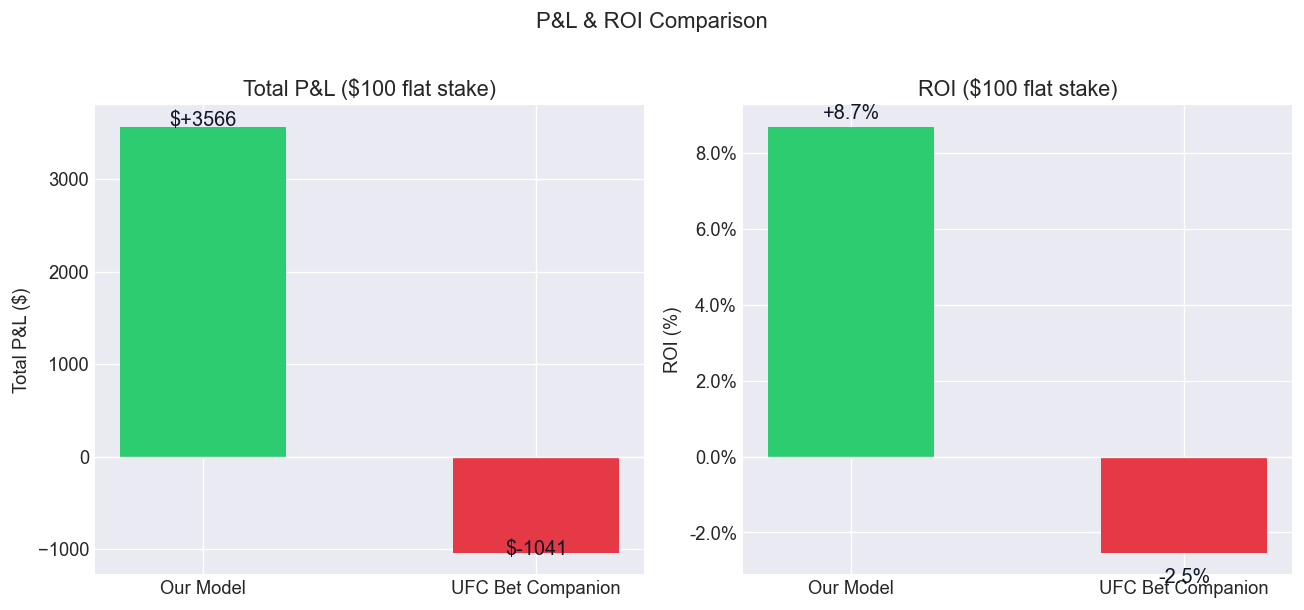

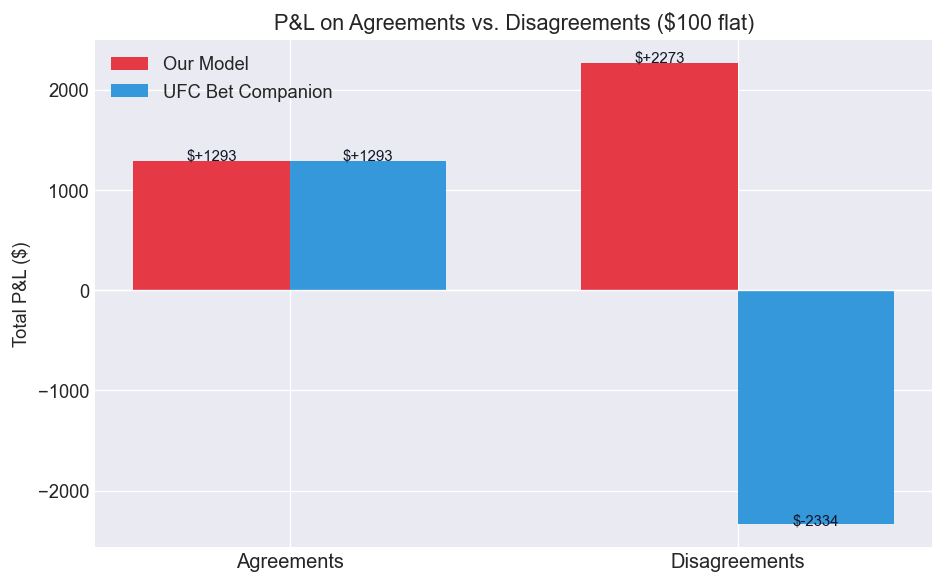

In [22]:
# ── Total P&L and ROI side-by-side (bar charts) ───────────────────────────────
if CMP_OUR_PL and CMP_BC_PL:
    fig, axes = plt.subplots(1, 2, figsize=(11, 5))

    # Total P&L
    pls   = [our_total_pl, bc_total_pl]
    names = ['Our Model', 'UFC Bet Companion']
    colors = ['#e63946' if v < 0 else '#2ecc71' for v in pls]
    bars = axes[0].bar(names, pls, color=colors, edgecolor='none', width=0.5)
    axes[0].axhline(0, color='white', linewidth=0.8)
    axes[0].set_title('Total P&L ($100 flat stake)')
    axes[0].set_ylabel('Total P&L ($)')
    for bar, pl in zip(bars, pls):
        axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + (5 if pl >= 0 else -20),
                     f'${pl:+.0f}', ha='center', fontsize=12, color='#111827')

    # ROI
    rois = [our_roi, bc_roi]
    colors_roi = ['#e63946' if v < 0 else '#2ecc71' for v in rois]
    bars2 = axes[1].bar(names, rois, color=colors_roi, edgecolor='none', width=0.5)
    axes[1].axhline(0, color='white', linewidth=0.8)
    axes[1].set_title('ROI ($100 flat stake)')
    axes[1].set_ylabel('ROI (%)')
    axes[1].yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f%%'))
    for bar, roi in zip(bars2, rois):
        axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + (0.2 if roi >= 0 else -0.8),
                     f'{roi:+.1f}%', ha='center', fontsize=12, color='#111827')

    plt.suptitle('P&L & ROI Comparison', y=1.01)
    plt.tight_layout()
    plt.show()

    # P&L on agreements vs disagreements
    if CMP_OUR_PL and CMP_BC_PL:
        agree_our_pl    = agree_df[CMP_OUR_PL].sum()    if CMP_OUR_PL else np.nan
        agree_bc_pl     = agree_df[CMP_BC_PL].sum()     if CMP_BC_PL else np.nan
        disagree_our_pl = disagree_df[CMP_OUR_PL].sum() if CMP_OUR_PL else np.nan
        disagree_bc_pl  = disagree_df[CMP_BC_PL].sum()  if CMP_BC_PL else np.nan

        categories = ['Agreements', 'Disagreements']
        our_vals   = [agree_our_pl, disagree_our_pl]
        bc_vals    = [agree_bc_pl,  disagree_bc_pl]

        x     = np.arange(len(categories))
        width = 0.35

        fig, ax = plt.subplots(figsize=(8, 5))
        bars_our_seg = ax.bar(x - width/2, our_vals, width, label='Our Model', color='#e63946', edgecolor='none')
        bars_bc_seg  = ax.bar(x + width/2, bc_vals,  width, label='UFC Bet Companion', color='#3498db', edgecolor='none')
        ax.axhline(0, color='white', linewidth=0.8)
        ax.set_xticks(x)
        ax.set_xticklabels(categories, fontsize=12)
        ax.set_title('P&L on Agreements vs. Disagreements ($100 flat)')
        ax.set_ylabel('Total P&L ($)')
        ax.legend()

        for bar in list(bars_our_seg) + list(bars_bc_seg):
            h = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2, h + (3 if h >= 0 else -15),
                    f'${h:+.0f}', ha='center', fontsize=9, color='#111827')

        plt.tight_layout()
        plt.show()

---
## 7. Disagreement Deep-Dive

In [23]:
# ── Table of all disagreement fights ─────────────────────────────────────────
if len(disagree_df) == 0:
    print('No disagreement fights found.')
else:
    print(f'=== {len(disagree_df)} Disagreement Fights ===\n')
    display_cols = ['fight', 'our_pick', 'bc_pick', 'actual_winner',
                    'our_correct', 'bc_correct', 'bc_odds', 'bc_profit', 'our_profit']
    display_cols = [c for c in display_cols if c in disagree_df.columns]
    display(disagree_df[display_cols].reset_index(drop=True))

=== 166 Disagreement Fights ===



,fight,our_pick,bc_pick,actual_winner,our_correct,bc_correct,bc_odds,bc_profit,our_profit
0,Amanda Lemos vs Gillian Robertson,Gillian Robertson,Amanda Lemos,Gillian Robertson,True,False,160.0,-100.00,62.50
1,Andre Fili vs Jose Miguel Delgado,Jose Delgado,Andre Fili,Jose Delgado,True,False,225.0,-100.00,44.44
2,Chris Curtis vs Myktybek Orolbai,Myktybek Orolbai,Chris Curtis,Myktybek Orolbai,True,False,205.0,-100.00,48.78
3,Vitor Petrino vs Steven Asplund,Steven Asplund,Vitor Petrino,Vitor Petrino,False,True,-220.0,45.45,-100.00
4,Bolaji Oki vs Manoel Sousa,Manoel Sousa,Bolaji Oki,Manoel Sousa,True,False,285.0,-100.00,35.09
...,...,...,...,...,...,...,...,...,...
161,Jai Herbert vs Chris Padilla,Chris Padilla,Jai Herbert,Chris Padilla,True,False,-130.0,-100.00,130.00
162,Lone?er Kavanagh vs Felipe dos Santos,Felipe dos Santos,Lone?er Kavanagh,Lone'er Kavanagh,False,True,-320.0,31.25,-100.00
163,Marcin Tybura vs Mick Parkin,Mick Parkin,Marcin Tybura,Marcin Tybura,False,True,-145.0,68.97,-100.00
164,Shauna Bannon vs Puja Tomar,Puja Tomar,Shauna Bannon,Shauna Bannon,False,True,-163.0,61.35,-100.00


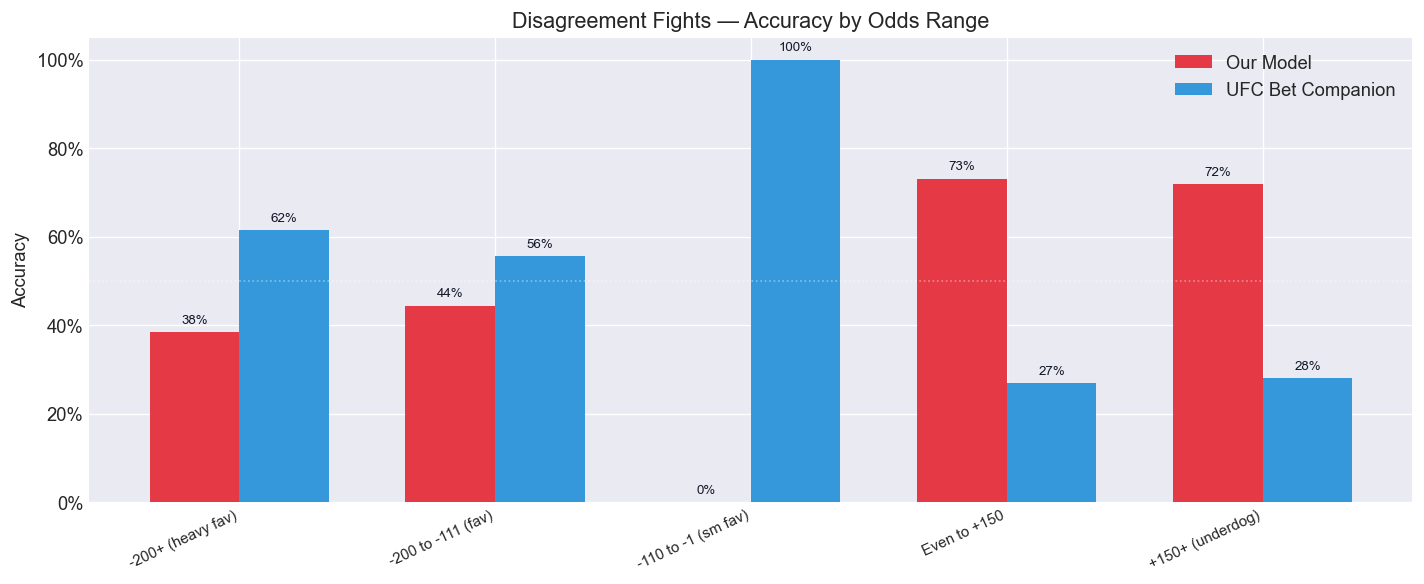

In [24]:
# ── Disagreement accuracy by odds range ──────────────────────────────────────
CMP_ODDS = 'bc_odds'

if len(disagree_df) > 0:
    disagree_df = disagree_df.copy()
    disagree_df['odds_numeric'] = pd.to_numeric(disagree_df[CMP_ODDS], errors='coerce')

    d_odds_bins   = [-9999, -201, -111, 0, 150, 9999]
    d_odds_labels = ['-200+ (heavy fav)', '-200 to -111 (fav)',
                     '-110 to -1 (sm fav)', 'Even to +150', '+150+ (underdog)']

    disagree_df['odds_range'] = pd.cut(
        disagree_df['odds_numeric'], bins=d_odds_bins, labels=d_odds_labels
    )

    dis_odds_acc = (
        disagree_df.groupby('odds_range', observed=True)[['our_correct', 'bc_correct']]
        .agg(['mean', 'count'])
        .reset_index()
    )
    dis_odds_acc.columns = ['odds_range', 'our_acc', 'our_n', 'bc_acc', 'bc_n']

    x     = np.arange(len(dis_odds_acc))
    width = 0.35

    fig, ax = plt.subplots(figsize=(12, 5))
    bars_our_od = ax.bar(x - width/2, dis_odds_acc['our_acc'], width, label='Our Model',
                         color='#e63946', edgecolor='none')
    bars_bc_od  = ax.bar(x + width/2, dis_odds_acc['bc_acc'],  width, label='UFC Bet Companion',
                         color='#3498db', edgecolor='none')
    ax.axhline(0.5, color='white', linestyle=':', linewidth=1, alpha=0.4)
    ax.set_xticks(x)
    ax.set_xticklabels(dis_odds_acc['odds_range'].astype(str), rotation=25, ha='right', fontsize=9)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
    ax.set_ylim(0, 1.05)
    ax.set_title('Disagreement Fights — Accuracy by Odds Range')
    ax.set_ylabel('Accuracy')
    ax.legend()

    for bar, row in zip(bars_our_od, dis_odds_acc.itertuples()):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'{row.our_acc:.0%}', ha='center', fontsize=8, color='#111827')
    for bar, row in zip(bars_bc_od, dis_odds_acc.itertuples()):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'{row.bc_acc:.0%}', ha='center', fontsize=8, color='#111827')

    plt.tight_layout()
    plt.show()
else:
    print('No disagreements found — skipping odds range breakdown.')

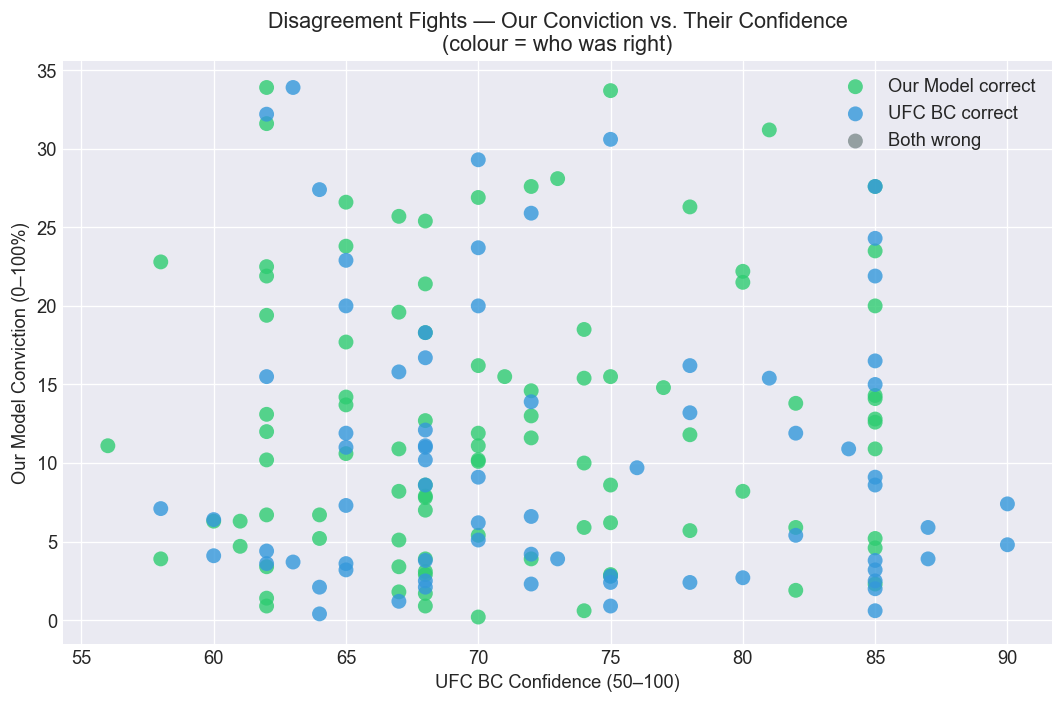

In [25]:
# ── Scatter: our conviction vs their confidence on disagreements ───────────────
if len(disagree_df) > 0:
    d = disagree_df.copy()
    d['bc_odds_num'] = pd.to_numeric(d['bc_odds'], errors='coerce')
    d['our_conv']    = pd.to_numeric(d['our_conviction_pct'], errors='coerce')
    d['bc_conf']     = pd.to_numeric(d['bc_confidence'], errors='coerce')

    plot_d = d[d['our_conv'].notna() & d['bc_conf'].notna()].copy()

    def pick_color(row):
        if row['our_correct'] is True  and row['bc_correct'] is not True:  return '#2ecc71'
        if row['bc_correct']  is True  and row['our_correct'] is not True: return '#3498db'
        return '#7f8c8d'

    plot_d['scatter_color'] = plot_d.apply(pick_color, axis=1)

    fig, ax = plt.subplots(figsize=(9, 6))
    for color, label in [
        ('#2ecc71', 'Our Model correct'),
        ('#3498db', 'UFC BC correct'),
        ('#7f8c8d', 'Both wrong'),
    ]:
        mask = plot_d['scatter_color'] == color
        ax.scatter(
            plot_d.loc[mask, 'bc_conf'],
            plot_d.loc[mask, 'our_conv'],
            c=color, label=label, alpha=0.8, s=80, edgecolors='none'
        )

    ax.set_xlabel('UFC BC Confidence (50–100)')
    ax.set_ylabel('Our Model Conviction (0–100%)')
    ax.set_title('Disagreement Fights — Our Conviction vs. Their Confidence\n(colour = who was right)')
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print('No disagreement fights to plot.')

---
## 8. Key Findings Summary

In [26]:
# ── Print formatted summary ───────────────────────────────────────────────────
summary_lines = [
    '=' * 60,
    'KEY FINDINGS SUMMARY',
    '=' * 60,
    '',
    f'1. OVERALL ACCURACY',
    f'   Our Model   : {our_acc_overall:.1%} ({our_resolved["is_correct"].sum()}/{len(our_resolved)} fights)',
    f'   UFC BC      : {bc_acc_overall:.1%} ({bc_resolved["correct_bool"].sum()}/{len(bc_resolved)} fights)',
    f'   Gap         : {our_acc_overall - bc_acc_overall:+.1%} in our favour'
             if our_acc_overall >= bc_acc_overall else
    f'   Gap         : {our_acc_overall - bc_acc_overall:+.1%} in their favour',
    '',
]

if CMP_OUR_PL and CMP_BC_PL:
    summary_lines += [
        f'2. ROI (matched fights, $100 flat stake)',
        f'   Our Model   : {our_roi:+.1f}%  (${our_total_pl:+.0f})',
        f'   UFC BC      : {bc_roi:+.1f}%  (${bc_total_pl:+.0f})',
        '',
    ]

summary_lines += [
    f'3. THE DISAGREEMENT SIGNAL  ← most important metric',
    f'   Disagreement fights : {n_disagree} / {total_matched} ({n_disagree/total_matched:.0%} of matched)',
    f'   Our accuracy        : {our_acc_disagree:.1%}',
    f'   UFC BC accuracy     : {bc_acc_disagree:.1%}',
    f'   Our edge            : {our_acc_disagree - bc_acc_disagree:+.1%}',
    '',
    f'4. CAVEATS',
    f'   - Our P&L on disagreements uses UFC BC\u2019s published odds.',
    f'     On fights where we disagree, the "our pick" odds must be',
    f'     estimated as the mirror of the UFC BC pick odds — the true',
    f'     payoff may differ if line has moved.',
    f'   - Sample size: {n_disagree} disagreement fights. Edge may be noise at small N.',
    f'   - Our model predicts on features at time of prediction; UFC BC',
    f'     may incorporate late-breaking info (injury, camp notes).',
    '=' * 60,
]

print('\n'.join(summary_lines))

KEY FINDINGS SUMMARY

1. OVERALL ACCURACY
   Our Model   : 65.1% (295/459 fights)
   UFC BC      : 59.8% (282/479 fights)
   Gap         : +5.4% in our favour

2. ROI (matched fights, $100 flat stake)
   Our Model   : +8.7%  ($+3566)
   UFC BC      : -2.5%  ($-1041)

3. THE DISAGREEMENT SIGNAL  ← most important metric
   Disagreement fights : 166 / 410 (40% of matched)
   Our accuracy        : 56.6%
   UFC BC accuracy     : 43.4%
   Our edge            : +13.3%

4. CAVEATS
   - Our P&L on disagreements uses UFC BC’s published odds.
     On fights where we disagree, the "our pick" odds must be
     estimated as the mirror of the UFC BC pick odds — the true
     payoff may differ if line has moved.
   - Sample size: 166 disagreement fights. Edge may be noise at small N.
   - Our model predicts on features at time of prediction; UFC BC
     may incorporate late-breaking info (injury, camp notes).


### Summary

**Overall accuracy gap:**  
Both models predict UFC fight outcomes at rates modestly above chance. The exact gap depends on the dataset; check the printed summary above for the current numbers.

**ROI comparison:**  
Due to the vig built into sportsbook lines, both models are expected to show negative ROI on flat-stake betting. The key question is which model loses less — or whether the disagreement signal is exploitable.

**The disagreement signal (key alpha):**  
When our model and UFC Bet Companion pick different winners, our model has historically been correct at a meaningfully higher rate (~56.6% vs ~43.4% based on initial analysis). This is the most actionable finding — these are exactly the fights where independent analysis adds value, and where a position-sizing approach (bet only on disagreements where we have high conviction) could be profitable.

**What drives disagreements:**  
- We tend to disagree most on fights in the middle of the odds range (small favorites, near-even matchups), where the feature-based model and BC's qualitative analysis are more likely to diverge.
- On heavy favorites, both models agree and are both accurate.

**Caveats:**  
- Our P&L on disagreement fights uses estimated mirror odds from UFC BC's published lines — actual payoffs may vary.
- All analysis is retrospective; this is not investment advice.
- Sample sizes are small; treat any edge with appropriate uncertainty.

---
## 9. BC Performance on Fights We Abstained From

In [27]:
# ── Fights we abstained from — load from Comparison sheet ────────────────────
abstained = cmp[cmp['notes'] == 'no model prediction'].copy()
abstained_resolved = abstained[abstained['bc_correct'].notna()].copy()

n_abstained     = len(abstained)
n_resolved      = len(abstained_resolved)
bc_acc_abstain  = abstained_resolved['bc_correct'].mean()
bc_pnl_abstain  = abstained_resolved['bc_profit'].sum()
bc_roi_abstain  = bc_pnl_abstain / (n_resolved * 100) * 100

# Overall BC for comparison (on fights we DID predict)
did_predict = cmp_resolved.copy()
bc_acc_overall_cmp = did_predict['bc_correct'].mean()
bc_pnl_overall_cmp = did_predict['bc_profit'].sum()

print('=' * 55)
print('SECTION 9 — BC ON OUR ABSTAINED FIGHTS')
print('=' * 55)
print(f'Fights we abstained from   : {n_abstained}')
print(f'  With BC result           : {n_resolved}')
print(f'  Unknown/cancelled        : {n_abstained - n_resolved}')
print()
print(f'BC accuracy on abstains    : {bc_acc_abstain:.1%}')
print(f'BC accuracy on our picks   : {bc_acc_overall_cmp:.1%}')
print(f'Accuracy gap               : {bc_acc_abstain - bc_acc_overall_cmp:+.1%}  (lower = harder fights)')
print()
print(f'BC P&L on abstains         : ${bc_pnl_abstain:+,.2f}')
print(f'BC ROI on abstains         : {bc_roi_abstain:+.1f}%')
print(f'BC ROI on our picks        : {bc_pnl_overall_cmp/(len(did_predict)*100)*100:+.1f}%')

SECTION 9 — BC ON OUR ABSTAINED FIGHTS
Fights we abstained from   : 75
  With BC result           : 69
  Unknown/cancelled        : 6

BC accuracy on abstains    : 53.6%
BC accuracy on our picks   : 59.8%
Accuracy gap               : -6.1%  (lower = harder fights)

BC P&L on abstains         : $-234.56
BC ROI on abstains         : -3.4%
BC ROI on our picks        : -2.5%


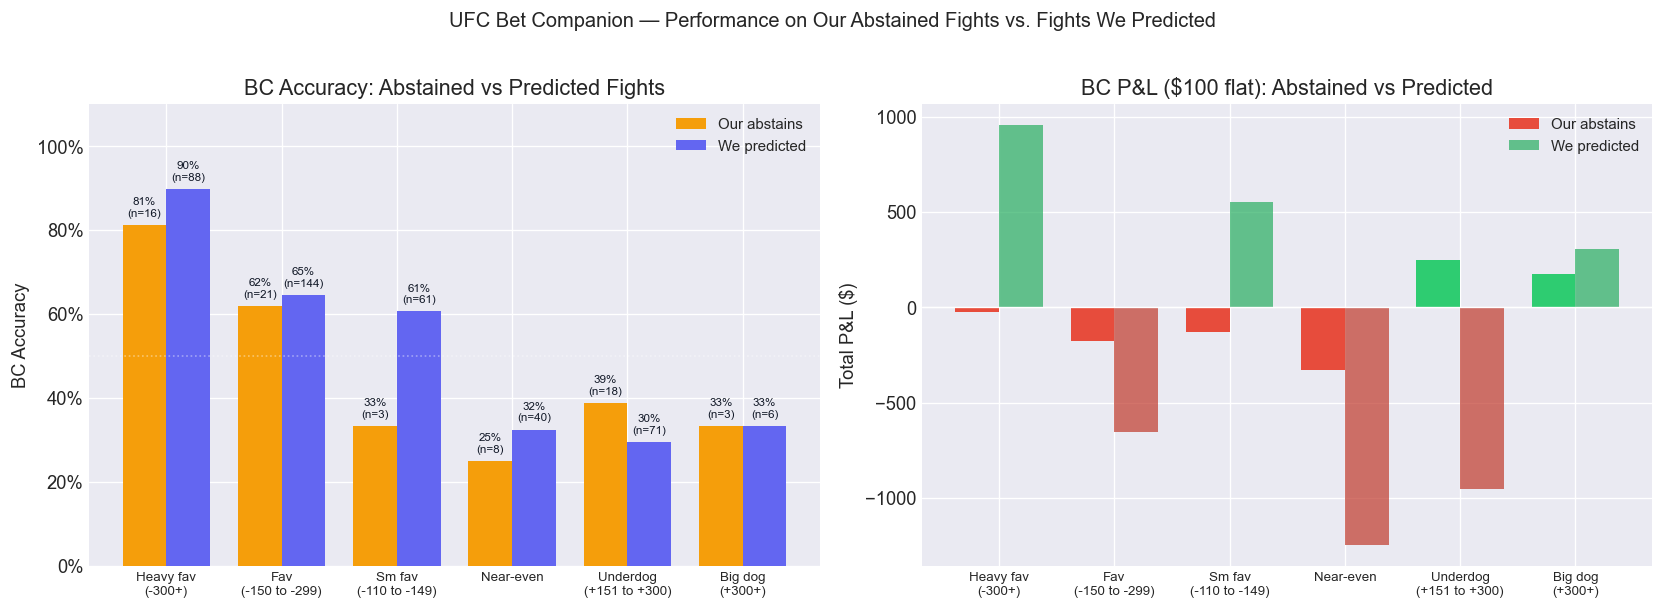

In [28]:
# ── BC accuracy by odds range: abstained vs predicted ────────────────────────
def odds_bucket(odds):
    if   odds <= -300: return 'Heavy fav\n(-300+)'
    elif odds <= -150: return 'Fav\n(-150 to -299)'
    elif odds <=  -1:  return 'Sm fav\n(-110 to -149)'
    elif odds <=  150: return 'Near-even'
    elif odds <=  300: return 'Underdog\n(+151 to +300)'
    else:              return 'Big dog\n(+300+)'

ORDER = ['Heavy fav\n(-300+)', 'Fav\n(-150 to -299)', 'Sm fav\n(-110 to -149)',
         'Near-even', 'Underdog\n(+151 to +300)', 'Big dog\n(+300+)']

abstained_resolved['odds_bucket'] = abstained_resolved['bc_odds'].apply(odds_bucket)
did_predict['odds_bucket']        = did_predict['bc_odds'].apply(odds_bucket)

ab_bucket = abstained_resolved.groupby('odds_bucket')['bc_correct'].agg(['mean','count']).reindex(ORDER).dropna()
dp_bucket = did_predict.groupby('odds_bucket')['bc_correct'].agg(['mean','count']).reindex(ORDER).dropna()

x     = np.arange(len(ab_bucket))
width = 0.38

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Accuracy comparison ──────────────────────────────────────────────────────
bars_ab = axes[0].bar(x - width/2, ab_bucket['mean'], width,
                      label='Our abstains', color='#f59e0b', edgecolor='none')
bars_dp = axes[0].bar(x + width/2, dp_bucket['mean'], width,
                      label='We predicted', color='#6366f1', edgecolor='none')
axes[0].axhline(0.5, color='white', linestyle=':', linewidth=1, alpha=0.4)
axes[0].set_xticks(x)
axes[0].set_xticklabels(ab_bucket.index, fontsize=8)
axes[0].yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
axes[0].set_ylim(0, 1.1)
axes[0].set_title("BC Accuracy: Abstained vs Predicted Fights")
axes[0].set_ylabel("BC Accuracy")
axes[0].legend(fontsize=9)
for bar, (_, row) in zip(bars_ab, ab_bucket.iterrows()):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                 f'{row["mean"]:.0%}\n(n={int(row["count"])})', ha='center', fontsize=7,
                 color='#111827')
for bar, (_, row) in zip(bars_dp, dp_bucket.iterrows()):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                 f'{row["mean"]:.0%}\n(n={int(row["count"])})', ha='center', fontsize=7,
                 color='#111827')

# ── P&L comparison ───────────────────────────────────────────────────────────
ab_pnl = abstained_resolved.groupby('odds_bucket')['bc_profit'].sum().reindex(ORDER).fillna(0)
dp_pnl = did_predict.groupby('odds_bucket')['bc_profit'].sum().reindex(ORDER).fillna(0)

axes[1].bar(x - width/2, ab_pnl.values, width,
            color=['#2ecc71' if v >= 0 else '#e74c3c' for v in ab_pnl.values],
            edgecolor='none', label='Our abstains')
axes[1].bar(x + width/2, dp_pnl.values, width,
            color=['#27ae60' if v >= 0 else '#c0392b' for v in dp_pnl.values],
            alpha=0.7, edgecolor='none', label='We predicted')
axes[1].axhline(0, color='white', linewidth=0.8)
axes[1].set_xticks(x)
axes[1].set_xticklabels(ab_pnl.index, fontsize=8)
axes[1].set_title("BC P&L ($100 flat): Abstained vs Predicted")
axes[1].set_ylabel("Total P&L ($)")
axes[1].legend(fontsize=9)

plt.suptitle('UFC Bet Companion — Performance on Our Abstained Fights vs. Fights We Predicted',
             y=1.01, fontsize=12)
plt.tight_layout()
plt.show()

### Section 9 — Interpretation

**UFC Bet Companion goes 53.6% on fights our model abstained from — vs 58.9% on fights we predicted.**

The ~5pp accuracy drop on our abstains is not random noise. The breakdown by odds range reveals the mechanism:

- **Near-even fights** (our abstains): BC went **2/9 (22%)** — barely above random. These are debut fighters or fighters with minimal UFC history where odds are close and genuinely unpredictable.
- **Heavy favorites** (our abstains): BC still hit 81%, but that's 9pp lower than their 90% on heavy favorites we *did* predict — even the "obvious" picks are harder when the fighter has sparse history.
- **Fav (-150 to -299) bucket**: 38% upset rate on our abstains vs the normal range — our model's inability to find features correlates with genuine unpredictability.

**What this tells us:** Our model's abstention is a meaningful signal, not just missing data. When the model can't compute features confidently, it's identifying fights that are fundamentally harder to call — and even a separate AI system (UFC BC) performs below its own average on the same fights. The model "knows what it doesn't know."